# Pre Proccess

In [38]:
import pandas as pd
from mysql_data_explorer import get_all_tables_from_mysql

all_tabels = get_all_tables_from_mysql()
print(all_tabels.keys())


✅ Connected to Azure MySQL database: dpu_fruitbot
📊 Found 4 tables: ['feedback_actions', 'user_choices', 'user_tutorial', 'users']


c:\Users\matan\master_thesis\rl_envs\procgen\experiments\mysql_data_explorer.py:83: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, self.connection)


   ✅ Loaded 'feedback_actions': 27067 rows, 13 columns
   ✅ Loaded 'user_choices': 2586 rows, 17 columns
   ✅ Loaded 'user_tutorial': 847 rows, 7 columns
   ✅ Loaded 'users': 1331 rows, 5 columns
🔌 Database connection closed
dict_keys(['feedback_actions', 'user_choices', 'user_tutorial', 'users'])


### Load and filter the users

In [39]:
# qualtrics_csv = "raw_data/qualtrics_demo1.csv"
qualtrics_csv = "raw_data/qualtrics2_values.csv"
qualtrics_df = pd.read_csv(qualtrics_csv)

# experiment 2 - pilot
# exp_start_time = pd.to_datetime("2026-03-10 00:00:00")
# exp_end_time = pd.to_datetime("2026-03-12 23:00:00")

# # experiment 1 - main
# exp_start_time = pd.to_datetime("2026-02-17 00:00:00")
# exp_end_time = pd.to_datetime("2026-02-20 23:00:00")

# experiment 2 - main
exp_start_time = pd.to_datetime("2026-03-25 00:00:00")
exp_end_time = pd.to_datetime("2026-03-31 23:00:00")

qualtrics_ids = qualtrics_df['ProlificID'].tolist()
qualtrics_df['StartDate'] = pd.to_datetime(qualtrics_df['StartDate'], errors='coerce')
qualtrics_df['EndDate'] = pd.to_datetime(qualtrics_df['EndDate'], errors='coerce')
# Filter the data
finish_check = 'True'
autentication_check = 'Strongly agree'
if 'values' in qualtrics_csv:
    finish_check = '1'
    autentication_check = '7'

print(f"raw data user number={len(qualtrics_df['ProlificID'])}")

def fill_autentication_check(qualtrics_df, autentication_check):
    # for users in group 0, fill the Q205_2 with the value of autentication_check
    group_0_users = qualtrics_df[qualtrics_df['group'] == '0'].index
    qualtrics_df.loc[group_0_users, 'Q205_2'] = autentication_check
    return qualtrics_df

qualtrics_df = fill_autentication_check(qualtrics_df, autentication_check)

relevant_qualtrics = qualtrics_df[
    (qualtrics_df['StartDate'] >= exp_start_time) & (qualtrics_df['StartDate'] <= exp_end_time) &
    (qualtrics_df['ProlificID'].astype(str).str.len() > 20) &
    (qualtrics_df['Finished'] == finish_check) & # Ensure the survey was completed
    (~qualtrics_df['ProlificID'].astype(str).str.contains('TEST', case=False, na=False)) &
    (qualtrics_df['Q205_2'] == autentication_check)  
]
print(f"relevant_qualtrics number of users={len(relevant_qualtrics['ProlificID'])}")

# take only users that where active in the game and participant by giving at least one feedback and choose an agent
user_choices = all_tabels['user_choices']
user_with_choice = user_choices['user_id'].unique().tolist()
users_to_remove_no_choice = relevant_qualtrics[~relevant_qualtrics['ProlificID'].isin(user_with_choice)]['ProlificID'].tolist()
relevant_qualtrics = relevant_qualtrics[relevant_qualtrics['ProlificID'].isin(user_with_choice)]

print(f"relevant_qualtrics users with choices={len(relevant_qualtrics['ProlificID'])}, users removed (no choices)={users_to_remove_no_choice}")

raw data user number=444
relevant_qualtrics number of users=298
relevant_qualtrics users with choices=268, users removed (no choices)=['672ff869852fc0175350f123', '699f9b235c0f08f5f51ecb2c@email.prolific.com', '6978cc6fec93939bff8fcb96', '69739c088b49d01ce0e25b8a', '69a0e6b3e0ca164870b35a35', '665b2efc3042735b842a170c', '6659f76ef9d2b27b7b615330', '5ba0df3c9c31af0001ff7795', '63bed6e176fba857a47fbaff', '6985e73e501c4df376a58abf', '59692f4467a8600001b714e1', '67e3281497a9f68c5c7ff062', '698d21c653f9cfdb05a407bf', '67bf82676da0b8cc04d81bd9', '654bb50c72b2f304d47bfdab', '5e909d6c5321c13abee11725', '657eff8c13ec3b61c3fabb3a', '6913757aae0da25ca51bdb7b', '67363cecd2581c03fbc2e070', '5d4043f25458cb0001d164a0', '67d8a842726644308266e91f', '67e268cbf13dcd115337894c', '6997a232168a53f1d28191e1', '69a7e18d4c24cacdbb47110c', '58d7ab1b31506e0001447859', '5ee4c4b42c280d1cd26cfe3d', '5f2aec6a4e6d4d428ab5bd8e', '67ac5f2b94b08886739a0003', '699ece8a778dfb99b080dfba', '69b9174a05fa2db6d0a8b4ff']


C:\Users\matan\AppData\Local\Temp\ipykernel_39532\3430677950.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  qualtrics_df['StartDate'] = pd.to_datetime(qualtrics_df['StartDate'], errors='coerce')
C:\Users\matan\AppData\Local\Temp\ipykernel_39532\3430677950.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  qualtrics_df['EndDate'] = pd.to_datetime(qualtrics_df['EndDate'], errors='coerce')


In [40]:
feedback_actions = all_tabels['feedback_actions']
feedback_actions.columns

Index(['id', 'user_id', 'env_state', 'agent_action', 'feedback_action',
       'feedback_explanation', 'action_index', 'timestamp', 'episode_index',
       'agent_name', 'similarity_level', 'env_level', 'env_config'],
      dtype='object')

In [41]:
def remove_duplicate_feedbacks(feedbacks_actions):
    # Step 1: Find the true (env_level, env_config) per (user_id, episode_index)
    # by taking the row with the latest timestamp, then drop rows that differ from it
    latest_env_idx = (
        feedbacks_actions
        .groupby(['user_id', 'episode_index'])['timestamp']
        .idxmax()
    )
    latest_env = (
        feedbacks_actions
        .loc[latest_env_idx, ['user_id', 'episode_index', 'env_level', 'env_config']]
        .rename(columns={'env_level': 'latest_env_level', 'env_config': 'latest_env_config'})
    )
    feedbacks_actions = feedbacks_actions.merge(latest_env, on=['user_id', 'episode_index'], how='left')
    feedbacks_actions = feedbacks_actions[
        (feedbacks_actions['env_level'] == feedbacks_actions['latest_env_level']) &
        (feedbacks_actions['env_config'] == feedbacks_actions['latest_env_config'])
    ]
    feedbacks_actions = feedbacks_actions.drop(columns=['latest_env_level', 'latest_env_config'])
    
    # Step 2: Among true duplicates (same user_id, episode_index, action_index),
    # keep only the row with the latest timestamp
    feedbacks_actions = (
        feedbacks_actions
        .sort_values('timestamp')
        .drop_duplicates(subset=['user_id', 'episode_index', 'action_index'], keep='last')
    )
    return feedbacks_actions.reset_index(drop=True)
feedback_actions = remove_duplicate_feedbacks(feedback_actions)


def remove_duplicate_choices(user_choices_results, relevant_qualtrics):
    # check if there are multiple choice items in the user_choices_results with the same user_id and episode_index, and keep the one with the highest timestamp
    relevant_ids = relevant_qualtrics['ProlificID'].tolist()
    user_choices_results = user_choices_results[user_choices_results['user_id'].isin(relevant_ids)]
    duplicate_choices = user_choices_results[user_choices_results.duplicated(['user_id', 'episode_index'], keep=False)]
    if not duplicate_choices.empty:
        print(f'the number of duplicate users are {duplicate_choices["user_id"].nunique()}')
        latest_choices = duplicate_choices.loc[duplicate_choices.groupby(['user_id', 'episode_index'])['timestamp'].idxmax()]
        user_choices_results = user_choices_results.drop(duplicate_choices.index)
        user_choices_results = pd.concat([user_choices_results, latest_choices], ignore_index=True)
    duplicate_choices = user_choices_results[user_choices_results.duplicated(['user_id', 'episode_index'], keep=False)]
    print(f"Duplicate choices after keeping latest: {duplicate_choices['user_id'].nunique()}")
    return user_choices_results

user_choices = remove_duplicate_choices(user_choices, relevant_qualtrics)
# remove users with more than 5 entries in the user_choices table
user_choice_counts = user_choices['user_id'].value_counts()
users_to_remove = user_choice_counts[user_choice_counts > 5].index.tolist()
print(f"users with more than 5 choices in user_choices table: {[id for id in relevant_qualtrics['ProlificID'].tolist() if id in users_to_remove]}")
relevant_qualtrics = relevant_qualtrics[~relevant_qualtrics['ProlificID'].isin(users_to_remove)]
print(f"relevant_qualtrics after remove users with more then 5 choices={len(relevant_qualtrics['ProlificID'])}")


# autentication check - remove users that failed the authentication check in the qualtrics survey
relevant_qualtrics = relevant_qualtrics[relevant_qualtrics['Q205_2'] == autentication_check]
print(f"relevant_qualtrics after remove users that failed the authentication check={len(relevant_qualtrics['ProlificID'])}")
# remove users with less then 3 feedbacks in the user_feedback table
user_feedback = all_tabels['feedback_actions']
user_feedback_counts = user_feedback['user_id'].value_counts()
users_to_remove = user_feedback_counts[user_feedback_counts < 3].index.tolist()
print(f"users with less than 3 feedbacks in user_feedback table: {[id for id in relevant_qualtrics['ProlificID'].tolist() if id in users_to_remove]}")
orig_qualtrics = relevant_qualtrics.copy()
relevant_qualtrics = relevant_qualtrics[~relevant_qualtrics['ProlificID'].isin(users_to_remove)]
print(f"relevant_qualtrics after remove users with less than 3 feedbacks={len(relevant_qualtrics['ProlificID'])}")


the number of duplicate users are 78
Duplicate choices after keeping latest: 0
users with more than 5 choices in user_choices table: []
relevant_qualtrics after remove users with more then 5 choices=268
relevant_qualtrics after remove users that failed the authentication check=268
users with less than 3 feedbacks in user_feedback table: ['5e991aaac7bc1615ea5b3eb8', '574aff1b5bef980007af2745', '6978e94c86ef2c792e089759', '6997b7e51e36044608c693d4', '69bf0527bafabf0e6be59f18', '6551469abe377d3646c6cd6e', '60fc12dc938ec5fd9284a25c', '601bd7b6f176775ca8d0cd76', '6134870de78084193e309662', '60314f566c0b9306e3956ebc', '652ae54b698bbd5c18c0c90e', '5cd4ad19f014930017d35d6a', '663127d07fb81f5532bcfdad', '5b17642244127b00013f7f65', '5f649a5cd14d460266092062', '646ff124ef129159bf5f08f7', '66929a6a268ccf0d6fce0d52', '695fd76cdc573c0c342fa134', '66ce77e3d21bb5b5d6a83d37', '698b39ff3d496d059a22c9f5', '66fdd81f708d36dbc86f85be']
relevant_qualtrics after remove users with less than 3 feedbacks=247


In [42]:
print("user number:", len(relevant_qualtrics['ProlificID'].unique()))
relevant_qualtrics['group'].value_counts()
# orig_qualtrics['group'].value_counts()

user number: 247


group
3    56
1    55
0    53
4    50
2    33
Name: count, dtype: int64

In [43]:
user_feedback[user_feedback['user_id'] == '69a1b6ac2a59612cb65dc825']

,id,user_id,env_state,agent_action,feedback_action,feedback_explanation,action_index,timestamp,episode_index,agent_name,similarity_level,env_level,env_config
14062,14063,69a1b6ac2a59612cb65dc825,None,0,2,,115,2026-03-26 15:51:05,4,1,1,66,3


In [44]:
# prolific_accepted1 = pd.read_csv("raw_data/prolific_accepted1.csv")
# prolific_accepted2 = pd.read_csv("raw_data/prolific_accepted2.csv")
# prolific_accepted = pd.concat([prolific_accepted1, prolific_accepted2], ignore_index=True)
# prolific_accepted_ids = prolific_accepted['Participant id'].tolist()
# in_q_in_p = set(relevant_qualtrics['ProlificID']).intersection(set(prolific_accepted_ids))
# in_q_nin_p = set(relevant_qualtrics['ProlificID']).difference(set(prolific_accepted_ids))
# in_p_nin_q = set(prolific_accepted_ids).difference(set(relevant_qualtrics['ProlificID']))
# print(f"IDs in both Qualtrics and Prolific: {len(in_q_in_p)}")
# print(f"IDs in Qualtrics but not in Prolific: {len(in_q_nin_p)}")
# print(f"IDs in Prolific but not in Qualtrics: {len(in_p_nin_q)}")

### Pre proccess

In [45]:
# columns pre-proccess
# Qualtrics
relevant_qualtrics['agent_level'] = (
    relevant_qualtrics['agent_level']
        .str.upper()
        .str.extract(r'APPL(\d)')
)

group_map = {'0': 'Control',
            "1": "Same",
             "2": "Similar",
             "3": "Salient-Contrast",
             "4": "Random"}
relevant_qualtrics['group_label'] = relevant_qualtrics['group'].astype(str).map(group_map)

trust_map = {
    'I will play myself': 0,
    'I will let the AI agent play': 1,
    '1': 0,
    '2': 1
}
relevant_qualtrics['trust_the_agent'] = relevant_qualtrics['Q594'].astype(str).str.strip().map(trust_map)


display(relevant_qualtrics.tail(3))


# Main app data
user_choices['timestamp'] = pd.to_datetime(user_choices['timestamp'], errors='coerce')
user_choices['demonstration_time'] = pd.to_datetime(user_choices['demonstration_time'], errors='coerce')
user_choices['choice_time'] = (user_choices['timestamp'] - user_choices['demonstration_time']).dt.total_seconds()

display(user_choices.tail(3))

,StartDate,EndDate,Status,IPAddress,Progress,Duration (in seconds),Finished,RecordedDate,ResponseId,RecipientLastName,...,comments,Q261,Random_ID,AWSURL,group,ProlificID,agent_level,bonus_group,group_label,trust_the_agent
440,2026-03-31 12:29:44,2026-03-31 12:54:58,0,75.157.126.226,100,1514,1,2026-03-31 12:54:59,R_52LTDohe3iUb7XG,NaN,...,NaN,NaN,2847452598,NaN,4,69137b85e53000767655dedc,NaN,2323,Random,0.0
441,2026-03-31 13:00:30,2026-03-31 13:17:19,0,99.247.236.163,100,1008,1,2026-03-31 13:17:20,R_6k1cnFuOs4i0Whu,NaN,...,NaN,NaN,8739787572,NaN,0,69aef912ddf5e3668448234a,NaN,2321,Control,0.0
442,2026-03-31 13:24:28,2026-03-31 13:52:32,0,90.240.150.248,100,1684,1,2026-03-31 13:52:32,R_2QclLBuGdeY2Hoo,NaN,...,I found it quite difficult to understand how t...,NaN,3394816872,NaN,3,67dc7c814cd5af9421e0476a,NaN,NaN,Salient-Contrast,1.0


,id,user_id,old_agent_name,new_agent_name,timestamp,demonstration_time,episode_index,choice_to_update,choice_explanation,similarity_level,feedback_score,feedback_count,env_level_feedback,env_level_demonstration,env_config_demonstration,agent_rating,feedback_correctness,choice_time
938,2341,69ca08e7817b325aabd1123d,5,4,2026-03-31 16:03:32,2026-03-31 16:03:32,2,1,,0,0.0,16,5,-1,-1,6.0,2.0,0.0
939,2348,69ca08e7817b325aabd1123d,4,5,2026-03-31 16:05:07,2026-03-31 16:05:07,4,1,,0,0.0,7,83,-1,-1,5.0,3.0,0.0
940,2355,69ca08e7817b325aabd1123d,5,6,2026-03-31 16:06:50,2026-03-31 16:06:50,5,1,,0,0.0,2,43,-1,-1,6.0,2.0,0.0


In [46]:
# Add tutorial scores to relevant_qualtrics
user_tutorial = all_tabels['user_tutorial']
episode_cols = ['episode_1_score', 'episode_2_score', 'episode_3_score', 'episode_4_score']
user_tutorial['tutorial_score'] = user_tutorial[episode_cols].mean(axis=1)
# Group by user_id and take the mean tutorial_score (in case there are multiple entries per user)
tutorial_scores = user_tutorial.groupby('user_id')['tutorial_score'].mean().reset_index()
tutorial_scores.columns = ['ProlificID', 'tutorial_score']
relevant_qualtrics = relevant_qualtrics.merge(tutorial_scores, on='ProlificID', how='left')
# relevant_qualtrics.tail(3)

In [47]:
user_choices.columns

Index(['id', 'user_id', 'old_agent_name', 'new_agent_name', 'timestamp',
       'demonstration_time', 'episode_index', 'choice_to_update',
       'choice_explanation', 'similarity_level', 'feedback_score',
       'feedback_count', 'env_level_feedback', 'env_level_demonstration',
       'env_config_demonstration', 'agent_rating', 'feedback_correctness',
       'choice_time'],
      dtype='object')

## Choices 

In [48]:
# remove the choices of users in the skip_choices list if they are in episode_index 5 (the last episode)
skip_5_choices = ['6765ef2feed02bfb60182ecb', '6647b26b402c0a3c5ab8b0cd', '6997c685f1620184f65cb8e9']
user_choices = user_choices[~((user_choices['user_id'].isin(skip_5_choices)) & (user_choices['episode_index'] == 5))]

In [49]:
models_scores_path = "C:\\Users\\matan\\master_thesis\\rl_envs\\procgen\\results\\simple_eval100.csv" #"../../results/models_results.csv"
models_scores = pd.read_csv(models_scores_path)
models_mean_scores = models_scores.groupby('model_index')['total_reward'].mean()
print(models_mean_scores)
models_mean_dict = {str(k): v for k, v in models_mean_scores.to_dict().items()}


model_index
1    2.5050
2    1.1900
3    4.4875
4    5.7400
5    6.4750
6    7.8950
Name: total_reward, dtype: float64


In [50]:
models_scores.columns

Index(['total_reward', 'episode_length', 'good_food_collected',
       'bad_food_touched', 'wall_hits', 'completed', 'model_index',
       'model_name', 'config_index', 'config_name', 'start_level'],
      dtype='object')

In [51]:
models_scores[(models_scores['config_index'] == 2) & (models_scores['start_level'] == 62) & (models_scores['model_index'] == 1)]#['total_reward']

,total_reward,episode_length,good_food_collected,bad_food_touched,wall_hits,completed,model_index,model_name,config_index,config_name,start_level
1262,-1.0,44,2,0,1,False,1,no_doors_collect_all,2,walls_doors_fruits,62


In [52]:
# Choice DF - create a new DF.
# for each user_id and for each episode_index make a row in the new DF with columns: 
# user_id, episode_index, choice, timestamp, board_level, group, trust_the_agent, demonstration_level, prev_agent, updated_agent
# choices = pd.DataFrame(columns=['user_id', 'episode_index', 'choice', 'prev_agent', 'updated_agent', 'timestamp', 'feedback_level', 'feedback_config', 'group', 'trust_the_agent', 'demonstration_level', 'demonstration_config', 'good_choice_local', 'good_choice_global'])
feedbacks_actions = all_tabels['feedback_actions']
feedbacks_actions = remove_duplicate_feedbacks(feedbacks_actions)
choices_list = []

for user_id in relevant_qualtrics['ProlificID'].unique():
    user_data = relevant_qualtrics[relevant_qualtrics['ProlificID'] == user_id]
    if user_data.empty:
        continue
    group = user_data['group'].values[0]
    trust_the_agent = user_data['trust_the_agent'].values[0]
    single_user_choices = user_choices[user_choices['user_id'] == user_id]
    user_feedbacks = feedbacks_actions[feedbacks_actions['user_id'] == user_id]
    # final_agent = user_final_agent(single_user_choices)
    for _, row in single_user_choices.iterrows():
        episode_index = row['episode_index']
        if episode_index < 1 or episode_index > 5:
            print(f"skipping row with episode_index {episode_index}")
            continue
        choice = row['choice_to_update']
        prev_agent = row['old_agent_name']
        updated_agent = row['new_agent_name']
        
        episode_feedbacks = user_feedbacks[user_feedbacks['episode_index'] == episode_index]
        if episode_feedbacks.empty:
            print(f"No feedback found for user_id {user_id} and episode_index {episode_index}")
            continue
        feedback_config = episode_feedbacks['env_config'].values[0]
        feedback_level = episode_feedbacks['env_level'].values[0]
        if group == '1' and row['env_level_feedback'] != feedback_level:
            print(f"Feedback level mismatch for user_id {user_id} and episode_index {episode_index}: user_choices level {row['env_level_feedback']} vs feedback_actions level {feedback_level}")
        
        # feedback score
        good_choice_local = 0
        prev_feedback_score = models_scores[
            (models_scores['config_index'].astype(str) == str(feedback_config)) & 
            (models_scores['start_level'].astype(str) == str(row['env_level_feedback'])) & 
            (models_scores['model_index'].astype(str) == str(prev_agent))
                ]['total_reward'].values

        updated_feedback_score = models_scores[
            (models_scores['config_index'].astype(str) == str(feedback_config)) & 
            (models_scores['start_level'].astype(str) == str(row['env_level_feedback'])) & 
            (models_scores['model_index'].astype(str) == str(updated_agent))
                ]['total_reward'].values
        if len(prev_feedback_score) == 0 or len(updated_feedback_score) == 0:
            print(f"No feedback scores found for user_id {user_id}, episode_index {episode_index}, prev_agent {prev_agent}, updated_agent {updated_agent}, ")
        else:
            if choice == 1 and updated_feedback_score[0] >= prev_feedback_score[0]:
                good_choice_local = 1
            elif choice == 0 and updated_feedback_score[0] <= prev_feedback_score[0]:
                good_choice_local = 1
        
        # global score
        good_choice_global = 1 if ((choice == 1) and (models_mean_dict[prev_agent] <= models_mean_dict[updated_agent])) or ((choice == 0) and (models_mean_dict[prev_agent] >= models_mean_dict[updated_agent])) else 0
        
        # demonstration score
        good_choice_demo = 0
        demo_prev_score = models_scores[
            (models_scores['config_index'].astype(str) == str(row['env_config_demonstration'])) & 
            (models_scores['start_level'].astype(str) == str(row['env_level_demonstration'])) & 
            (models_scores['model_index'].astype(str) == str(prev_agent))
                ]['total_reward'].values
        demo_updated_score = models_scores[
            (models_scores['config_index'].astype(str) == str(row['env_config_demonstration'])) & 
            (models_scores['start_level'].astype(str) == str(row['env_level_demonstration'])) & 
            (models_scores['model_index'].astype(str) == str(updated_agent))
                ]['total_reward'].values
        if (len(demo_prev_score) == 0 or len(demo_updated_score) == 0):
            if group != '0':
                print(f"No demonstration scores found for user_id {user_id}, episode_index {episode_index}, prev_agent {prev_agent}, updated_agent {updated_agent}, ")
        else:
            if choice == 1 and demo_updated_score[0] >= demo_prev_score[0]:
                good_choice_demo = 1
            elif choice == 0 and demo_updated_score[0] <= demo_prev_score[0]:
                good_choice_demo = 1


        new_row = pd.DataFrame([{
            'user_id': user_id,
            'episode_index': episode_index,
            'group': group,
            'prev_agent': prev_agent,
            'updated_agent': updated_agent,
            'choice': choice,
            'good_choice_local': good_choice_local,
            'good_choice_global': good_choice_global,
            'good_choice_demo': good_choice_demo,
            'feedback_config': feedback_config,
            'feedback_level': row['env_level_feedback'],
            'demonstration_config': row['env_config_demonstration'],
            'demonstration_level': row['env_level_demonstration'],
            'demo_prev_score': demo_prev_score[0] if len(demo_prev_score) > 0 else None,
            'demo_updated_score': demo_updated_score[0] if len(demo_updated_score) > 0 else None,
            'update_agent_mean_score': models_mean_dict[updated_agent] if updated_agent in models_mean_dict else None,
            'prev_agent_mean_score': models_mean_dict[prev_agent] if prev_agent in models_mean_dict else None,
            'updated_agent_feedback_score': updated_feedback_score[0] if len(updated_feedback_score) > 0 else None,
            'prev_agent_feedback_score': prev_feedback_score[0] if len(prev_feedback_score) > 0 else None,
            'feedback_count': row['feedback_count'],
            'feedback_correctness': row['feedback_correctness'],
            'agent_rating': row['agent_rating'],
            'trust_the_agent': trust_the_agent,
            'choice_time': row['choice_time'],
        }])
        # print(new_row)
        choices_list.append(new_row)

    #     break
    # break


choices_results = pd.concat(choices_list, ignore_index=True)
# print(choices_results.head(2))

        

No feedback found for user_id 69975af56e47c98f4a633844 and episode_index 3
No feedback found for user_id 60524a9ece19f6b376473cf7 and episode_index 4
No feedback found for user_id 5f16f603b73bff000888fae1 and episode_index 4
No feedback found for user_id 5f16f603b73bff000888fae1 and episode_index 5
No feedback found for user_id 62fb8ef806ee6962abefc45e and episode_index 5
No feedback found for user_id 613a415ae2f1292f97385a12 and episode_index 5
No feedback found for user_id 699632a125fb1bd95501ef4d and episode_index 3
No feedback found for user_id 699632a125fb1bd95501ef4d and episode_index 5
skipping row with episode_index 6
No feedback found for user_id 669130d95c30296d7607df8f and episode_index 2
No feedback found for user_id 69ca08e7817b325aabd1123d and episode_index 3
No feedback found for user_id 69ab8bf45a6e9cf1be1f8280 and episode_index 4
No feedback found for user_id 67b5ce073a599cc12ebadb78 and episode_index 3
No feedback found for user_id 696052c668bf5df05dc13a7a and episode

C:\Users\matan\AppData\Local\Temp\ipykernel_39532\3503957870.py:115: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  choices_results = pd.concat(choices_list, ignore_index=True)


In [53]:
user_tutorial_df = all_tabels['user_tutorial']
users_df = all_tabels['users']
users_df['final_score'].unique()

array([nan, 23., 10., -3., -2., -4., -5., -6., -1., 19., 20., 13., 11.,
       -7.,  0., 18.,  1., 21., 22., 24.,  7.])

In [54]:
relevant_qualtrics.columns

Index(['StartDate', 'EndDate', 'Status', 'IPAddress', 'Progress',
       'Duration (in seconds)', 'Finished', 'RecordedDate', 'ResponseId',
       'RecipientLastName',
       ...
       'Q261', 'Random_ID', 'AWSURL', 'group', 'ProlificID', 'agent_level',
       'bonus_group', 'group_label', 'trust_the_agent', 'tutorial_score'],
      dtype='object', length=108)

In [55]:
## User - DF.
# for each user save the user data, group, trust_the_agent, final_agent, tutorial_score, final_score, mean_feedback_count, number_of_choices, mean_good_choice_local, mean_good_choice_global
qualtrics_columns = ['ProlificID', 'group', 'group_label', 'trust_the_agent', 'Q175', 'Q203_1', 'tutorial_score', 'age', 'gender', 'education', 'ai', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5', 'Q205_1', 'Q205_3',  'Q205_4', 'Q205_5', 'Q205_6']
user_question_mapping = {
    'Q205_1': "The explanations of the agent's paths were clear and easy to understand",
    'Q205_3': "The explanations felt too detailed and overwhelming",
    'Q205_4': "The explanations helped me see how my feedback changed the agent's behavior",
    'Q205_5':"The visual demonstrations of policy changes helped me understand the differences between agents",
    'Q205_6': "My feedback helped improve the agent's performance",
    "ai:": "How familiar are you with Artificial Intelligence?",
    "AI_1": "I believe AI will improve my life",
    "AI_2": "I believe that AI will improve my work",
    "AI_3": "I think I will use AI technology in the future",
    "AI_4": "I think AI technology is a threat to humans",
    "AI_5": "I think AI technology is positive for humanity",
}

agent_ranking = {1: 2, 2: 1, 3: 3, 4: 4, 5: 5, 6: 6}
def user_final_agent(user_choices_data):
    episode_indexes = user_choices_data['episode_index']
    last_choice = user_choices_data[user_choices_data['episode_index'] == episode_indexes.max()].iloc[0]
    
    choice = last_choice['choice_to_update']
    if choice == 1:
        return last_choice['new_agent_name']
    else:
        return last_choice['old_agent_name']
    
user_results = relevant_qualtrics[qualtrics_columns].copy()
user_results.rename(columns={'ProlificID': 'user_id', 'Q175': 'trust_explanations', 'Q203_1': 'evaluate_final_agent'}, inplace=True)
user_results['final_agent'] = user_results['user_id'].apply(
    lambda uid: user_final_agent(user_choices[user_choices['user_id'] == uid])
)

user_results['final_agent'] = pd.to_numeric(user_results['final_agent'], errors='coerce').astype('Int64')
user_results['final_agent_rank'] = user_results['final_agent'].map(agent_ranking).astype('Int64')
for _, row in user_results.iterrows():
    user_id = row['user_id']
    single_user_choices = choices_results[choices_results['user_id'] == user_id]

    choice_count = len(single_user_choices)
    feedback_count = single_user_choices['feedback_count'].sum()
    user_results.loc[user_results['user_id'] == user_id, 'number_of_choices'] = choice_count
    user_results.loc[user_results['user_id'] == user_id, 'mean_feedback_count'] = feedback_count / choice_count if choice_count > 0 else 0
    user_results.loc[user_results['user_id'] == user_id, 'mean_good_choice_local'] = single_user_choices['good_choice_local'].mean()
    user_results.loc[user_results['user_id'] == user_id, 'mean_good_choice_global'] = single_user_choices['good_choice_global'].mean()
    user_results.loc[user_results['user_id'] == user_id, 'mean_good_choice_demo'] = single_user_choices['good_choice_demo'].mean()
    user_results.loc[user_results['user_id'] == user_id, 'mean_agent_rating'] = single_user_choices['agent_rating'].mean()
    
    
    # tutorial_score = user_tutorial_df[user_tutorial_df['user_id'] == user_id]['tutorial_score'].values
    # user_results.loc[user_results['user_id'] == user_id, 'tutorial_score'] = tutorial_score[0] if len(tutorial_score) > 0 else None

    final_score = users_df[users_df['user_id'] == user_id]['final_score'].values
    user_results.loc[user_results['user_id'] == user_id, 'final_score'] = final_score[0] if len(final_score) > 0 else None

user_results.head(2)


,user_id,group,group_label,trust_the_agent,trust_explanations,evaluate_final_agent,tutorial_score,age,gender,education,...,Q205_6,final_agent,final_agent_rank,number_of_choices,mean_feedback_count,mean_good_choice_local,mean_good_choice_global,mean_good_choice_demo,mean_agent_rating,final_score
0,69b03531db81dab44c5b09a4,0,Control,1.0,I want to see how my feedback works in practice,5,-1.5,50,1,4,...,NaN,1,2,2.0,6.5,0.5,0.5,0.0,4.0,NaN
1,5b25740da7cee100011d884b,0,Control,0.0,I feel I may be able to perform better as I ha...,6,3.5,33,0,2,...,NaN,6,6,2.0,13.5,0.5,1.0,0.0,4.5,NaN


In [56]:
# Map group labels on choices_results
_gm = {"0": "Control", "1": "Same", "2": "Similar", "3": "Contrast", "4": "Random"}
choices_results['group_label'] = choices_results['group'].astype(str).map(_gm)

# Did the updated agent improve over prev on the feedback level?
def _improved_fb(row):
    try:
        fc, fl = str(int(row['feedback_config'])), str(int(row['feedback_level']))
    except:
        return None
    ms = models_scores
    prev = ms[(ms['config_index'].astype(str)==fc)&(ms['start_level'].astype(str)==fl)&(ms['model_index'].astype(str)==str(row['prev_agent']))]['total_reward'].values
    upd  = ms[(ms['config_index'].astype(str)==fc)&(ms['start_level'].astype(str)==fl)&(ms['model_index'].astype(str)==str(row['updated_agent']))]['total_reward'].values
    return int(upd[0] > prev[0]) if len(prev) > 0 and len(upd) > 0 else None

choices_results['improved_from_prev_feedback'] = choices_results.apply(_improved_fb, axis=1)
choices_results['improved_from_prev_mean'] = choices_results.apply(
    lambda r: int(models_mean_dict.get(str(r['updated_agent']),0) > models_mean_dict.get(str(r['prev_agent']),0)), axis=1)

# Final agent mean score
user_results['final_agent_mean_score'] = user_results['final_agent'].map(lambda x: models_mean_dict.get(str(x)))

print("Ready — choices:", choices_results.shape, "| users:", user_results.shape)

Ready — choices: (893, 27) | users: (247, 31)


In [57]:
# save the results to csv files
save_path = 'choices_final_results.csv'
choices_results.to_csv(save_path, index=False)

save_path = 'user_final_results.csv'
user_results.to_csv(save_path, index=False)

### Combined Results

In [58]:
ES_questions = {'ai': 'familiar_with_AI',
                'Q205_1': 'ES_understandable',
                'Q205_3': 'ES_overwhelming',
                'Q205_4': 'ES_feedback_related',
                'Q205_5': 'ES_helpful',
                'Q205_6': 'ES_improvement',
                'user_satisfaction': 'ES_combined'}
# user_results['user_satisfaction'] = (
#     user_results['Q205_1'] - 
#     user_results['Q205_3'] + 
#     user_results['Q205_4'] + 
#     user_results['Q205_5'] + 
#     user_results['Q205_6']
# ) / 5
for q, new_col in ES_questions.items():
    user_results.rename(columns={q: new_col}, inplace=True)
user_results.columns


Index(['user_id', 'group', 'group_label', 'trust_the_agent',
       'trust_explanations', 'evaluate_final_agent', 'tutorial_score', 'age',
       'gender', 'education', 'familiar_with_AI', 'AI_1', 'AI_2', 'AI_3',
       'AI_4', 'AI_5', 'ES_understandable', 'ES_overwhelming',
       'ES_feedback_related', 'ES_helpful', 'ES_improvement', 'final_agent',
       'final_agent_rank', 'number_of_choices', 'mean_feedback_count',
       'mean_good_choice_local', 'mean_good_choice_global',
       'mean_good_choice_demo', 'mean_agent_rating', 'final_score',
       'final_agent_mean_score'],
      dtype='object')

In [59]:
columns_to_remove = ['trust_explanations', 'tutorial_score', 'mean_feedback_count']
user_results_for_combined_df = user_results.drop(columns=columns_to_remove)
user_results_for_combined_df = user_results_for_combined_df[user_results_for_combined_df['group_label'] != 'Similar']
user_results_for_combined_df.to_csv('combined_results/user_results_for_combined_fruitbot_df.csv', index=False)

In [138]:
user_results_for_combined_df['group_label'].value_counts()

group_label
Salient-Contrast    56
Same                55
Control             53
Random              50
Name: count, dtype: int64

In [60]:
user_results_for_combined_df['final_agent_rank'].value_counts()

final_agent_rank
6    75
5    56
4    30
2    25
3    25
1     3
Name: count, dtype: Int64

In [136]:
# combine choice results
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'feedback_config', 'feedback_level', 'demonstration_config',
       'demonstration_level', 'demo_prev_score', 'demo_updated_score',
       'update_agent_mean_score', 'prev_agent_mean_score',
       'updated_agent_feedback_score', 'prev_agent_feedback_score',
       'feedback_count', 'feedback_correctness', 'agent_rating',
       'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean'],
      dtype='object')

In [140]:
choices_results_for_combined_df = choices_results[choices_results['group_label'] != 'Similar']
choices_results_for_combined_df.to_csv('combined_results/choice_results_for_combined_fruitbot_df.csv', index=False)

## Conflicting Choices

In [24]:
models_neighbors = {
  1: {
    2: {'name': 'no_doors_junk_only', 'contrast_config': 2, 'configs': [[35, 7], [63, 2], [48, 8], [41, 91]]},
    3: {'name': 'no_doors_fruits_only', 'contrast_config': 0, 'configs': [[51, 28], [2, 1], [28, 57], [43, 22]]},
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 2, 'configs': [[43, 16], [47, 79], [97, 43], [50, 67]]},
    5: {'name': 'mostly_fruits_open_doors', 'contrast_config': 3, 'configs': [[51, 16], [2, 96], [80, 55], [53, 74]]}
  },  2: {
    1: {'name': 'no_doors_collect_all', 'contrast_config': 2, 'configs': [[35, 7], [63, 2], [48, 8], [41, 91]]},
    3: {'name': 'no_doors_fruits_only', 'contrast_config': 0, 'configs': [[25, 44], [2, 63], [48, 93], [41, 66]]},
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 1, 'configs': [[46, 65], [2, 34], [58, 9], [87, 41]]}
  },  3: {
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 0, 'configs': [[44, 69], [75, 34], [9, 31], [34, 79]]},
    5: {'name': 'mostly_fruits_open_doors', 'contrast_config': 3, 'configs': [[74, 54], [16, 79], [99, 57], [18, 15]]},
    6: {'name': 'open_doors_fruits_only', 'contrast_config': 3, 'configs': [[74, 39], [1, 94], [97, 43], [28, 18]]}
  },  4: {
    1: {'name': 'no_doors_collect_all', 'contrast_config': 2, 'configs': [[43, 16], [47, 79], [97, 43], [50, 67]]},
    5: {'name': 'mostly_fruits_open_doors', 'contrast_config': 3, 'configs': [[69, 51], [67, 66], [41, 47], [78, 4]]},
    6: {'name': 'open_doors_fruits_only', 'contrast_config': 2, 'configs': [[67, 51], [64, 76], [22, 43], [85, 96]]}
  },  5: {
    2: {'name': 'no_doors_junk_only', 'contrast_config': 1, 'configs': [[46, 74], [63, 2], [47, 29], [41, 87]]},
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 0, 'configs': [[69, 51], [67, 66], [41, 47], [78, 71]]},
    6: {'name': 'open_doors_fruits_only', 'contrast_config': 3, 'configs': [[49, 2], [76, 43], [22, 31], [96, 30]]}
  },  6: {
    1: {'name': 'no_doors_collect_all', 'contrast_config': 1, 'configs': [[51, 59], [47, 91], [30, 79], [53, 46]]},
    3: {'name': 'no_doors_fruits_only', 'contrast_config': 2, 'configs': [[74, 39], [1, 94], [13, 51], [28, 18]]},
    4: {'name': 'open_doors_avoid_food', 'contrast_config': 0, 'configs': [[67, 51], [64, 76], [22, 43], [85, 96]]},
    5: {'name': 'mostly_fruits_open_doors', 'contrast_config': 3, 'configs': [[49, 2], [31], [22, 31], [96, 30]]}
  }}  
choices_results.columns


Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'feedback_config', 'feedback_level', 'demonstration_config',
       'demonstration_level', 'demo_prev_score', 'demo_updated_score',
       'feedback_count', 'feedback_correctness', 'agent_rating',
       'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean'],
      dtype='object')

In [25]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'feedback_config', 'feedback_level', 'demonstration_config',
       'demonstration_level', 'demo_prev_score', 'demo_updated_score',
       'feedback_count', 'feedback_correctness', 'agent_rating',
       'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean'],
      dtype='object')

In [26]:
group_i = 2
group_df = choices_results[choices_results['group'] == str(group_i)]

contradictory_choices = group_df[(group_df['good_choice_local'] == 1) & (group_df['good_choice_global'] == 0)][['user_id', 'episode_index', 'prev_agent', 'updated_agent', 'choice',
                                                                         'good_choice_demo', 'good_choice_global', 'good_choice_local',
                                                                         'demonstration_config', 'demonstration_level', 'demo_prev_score', 'demo_updated_score',
                                                                         'feedback_config', 'feedback_level', 'choice_time', 'agent_rating']]
print(len(contradictory_choices))
display(contradictory_choices)

6


,user_id,episode_index,prev_agent,updated_agent,choice,good_choice_demo,good_choice_global,good_choice_local,demonstration_config,demonstration_level,demo_prev_score,demo_updated_score,feedback_config,feedback_level,choice_time,agent_rating
105,69b35c87e60a69208c2369b9,2,5,4,1,0,0,1,3,78,13.0,-5.0,3,24,19.0,5.0
203,698d17af742636fbd4e4a9c2,2,1,4,0,0,0,1,0,16,7.0,10.0,0,34,18.0,7.0
290,68123a73ba06c472ccd5edb8,2,1,4,0,1,0,1,3,67,-4.0,-6.0,3,43,12.0,5.0
321,6313bb3b3d3981dc7402a033,2,1,5,0,0,0,1,1,2,6.0,10.0,1,53,14.0,5.0
323,6313bb3b3d3981dc7402a033,4,1,3,0,1,0,1,2,57,14.0,14.0,2,78,15.0,4.0
589,64e36d981d00e7d7c45addc2,2,1,4,0,1,0,1,0,43,13.0,10.0,0,14,23.0,4.0


In [27]:
choices_to_remove = [('69b04ae112b55b3a183c8ea9', 2),
                     ('698c054ad44c45a1061327b9', 3),
                     ('698c054ad44c45a1061327b9', 5),
                     ('673f6ffebce20832346325de', 1),
                     ('69ac96e9cf57af07fdd54227', 4),
                     ('5805db219ff6120001a135a2', 1),
                     ('69832ecb3693ee29d4fcc3c6', 2),
                     ('6765ef2feed02bfb60182ecb', 4),
                     ('69c429803583836ef035bd0d', 1),
                     ('66b1375b72c3a0f57828dcca', 3),
                     ('6913b066f2c9da9a92afc734', 3),
                     ('69ac9523ad63eebc23c358ec', 4),
                     ('65313bdcb9fd825a8c1d4981', 4),
                     ('678b6eba161e3e871bbafef5', 3),
                     ('6651e7f3cec5c25f42720bfa', 1)
                     ]

In [28]:
#filtered_choices
print(f"Number of choices before removal: {len(choices_results)}")
filtered_choices_results = choices_results[~choices_results.set_index(['user_id', 'episode_index']).index.isin(choices_to_remove)]
print(f"Number of choices after removal: {len(filtered_choices_results)}")

Number of choices before removal: 893
Number of choices after removal: 893


In [29]:
models_scores = pd.read_csv('C:\\Users\\matan\\master_thesis\\rl_envs\\procgen\\results\\simple_eval100.csv')
models_scores[(models_scores['model_index'] == 5) & 
              (models_scores['config_index'] == 1) & 
              (models_scores['start_level'] == 43)]['total_reward'].values

array([-4.])

In [30]:
# Find (config, level) tuples where local score order is opposite to global mean score order
# Rule:
# 1) model score at (config, level) > neighbor score, but model mean < neighbor mean
# OR
# 2) model score at (config, level) < neighbor score, but model mean > neighbor mean

interesting_levels = []
models_mean_scores = models_scores.groupby('model_index')['total_reward'].mean()

missing_pairs = []

for model_idx, neighbors in models_neighbors.items():
    model_mean = models_mean_scores.get(model_idx, -100)  # Default to -100 if model_idx not found

    for neighbor_idx, neighbor_info in neighbors.items():
        neighbor_mean = models_mean_scores.get(neighbor_idx, -100)  # Default to -100 if neighbor_idx not found

        if model_mean == -100 or neighbor_mean == -100:
            print(f"Warning: Missing mean score for model {model_idx} or neighbor {neighbor_idx}. Skipping comparison.")
            continue

        # config_idx is the position in the list: 0, 1, 2, 3
        for config_idx, levels_in_config in enumerate(neighbor_info['configs']):
            for level in levels_in_config:
                m1_vals = models_scores[
                    (models_scores['model_index'] == model_idx)
                    & (models_scores['config_index'] == config_idx)
                    & (models_scores['start_level'] == level)
                ]['total_reward'].values

                m2_vals = models_scores[
                    (models_scores['model_index'] == neighbor_idx)
                    & (models_scores['config_index'] == config_idx)
                    & (models_scores['start_level'] == level)
                ]['total_reward'].values

                if len(m1_vals) == 0 or len(m2_vals) == 0:
                    missing_pairs.append((model_idx, neighbor_idx, config_idx, level))
                    print(f"Warning: Missing score data for model {model_idx} or neighbor {neighbor_idx} at config {config_idx}, level {level}. Skipping comparison.")
                    continue

                local_m1 = float(m1_vals[0])
                local_m2 = float(m2_vals[0])

                # Opposite order between local and global comparison
                cond_1 = (local_m1 > local_m2) and (model_mean < neighbor_mean)
                cond_2 = (local_m1 < local_m2) and (model_mean > neighbor_mean)

                if cond_1 or cond_2:
                    interesting_levels.append({
                        'model_1': model_idx,
                        'neighbor': neighbor_idx,
                        # 'neighbor_name': neighbor_info.get('name'),
                        'config_index': config_idx,
                        'level': level,
                        'model_1_local_score': local_m1,
                        'neighbor_local_score': local_m2,
                        # 'local_diff_m1_minus_neighbor': local_m1 - local_m2,
                        'model_1_mean_score': float(model_mean),
                        'neighbor_mean_score': float(neighbor_mean),
                        # 'global_diff_m1_minus_neighbor': float(model_mean - neighbor_mean),
                        'direction': 'm1_local_better_but_global_worse' if cond_1 else 'm1_local_worse_but_global_better'
                    })

interesting_levels_df = pd.DataFrame(interesting_levels)

if interesting_levels_df.empty:
    print('No opposite-order (config, level) tuples found with the current models_neighbors mapping.')
else:
    interesting_levels_df = interesting_levels_df.sort_values(
        by=['config_index', 'level', 'model_1', 'neighbor']
    ).reset_index(drop=True)

    print(f"Found {len(interesting_levels_df)} opposite-order tuples")
    display(interesting_levels_df)

if missing_pairs:
    print(f"Skipped {len(missing_pairs)} tuples due to missing score rows in models_scores")

Found 11 opposite-order tuples


,model_1,neighbor,config_index,level,model_1_local_score,neighbor_local_score,model_1_mean_score,neighbor_mean_score,direction
0,1,4,0,43,13.0,10.0,2.5050,5.7400,m1_local_better_but_global_worse
1,4,1,0,43,10.0,13.0,5.7400,2.5050,m1_local_worse_but_global_better
2,3,4,0,44,14.0,9.0,4.4875,5.7400,m1_local_better_but_global_worse
3,3,5,0,54,14.0,11.0,4.4875,6.4750,m1_local_better_but_global_worse
4,3,4,0,69,14.0,9.0,4.4875,5.7400,m1_local_better_but_global_worse
5,3,6,1,1,10.0,8.0,4.4875,7.8950,m1_local_better_but_global_worse
6,6,3,1,1,8.0,10.0,7.8950,4.4875,m1_local_worse_but_global_better
7,4,5,1,66,10.0,6.0,5.7400,6.4750,m1_local_better_but_global_worse
8,5,4,1,66,6.0,10.0,6.4750,5.7400,m1_local_worse_but_global_better
9,1,4,3,67,-4.0,-6.0,2.5050,5.7400,m1_local_better_but_global_worse


In [31]:
interesting_levels

[{'model_1': 1,
  'neighbor': 4,
  'config_index': 0,
  'level': 43,
  'model_1_local_score': 13.0,
  'neighbor_local_score': 10.0,
  'model_1_mean_score': 2.505,
  'neighbor_mean_score': 5.74,
  'direction': 'm1_local_better_but_global_worse'},
 {'model_1': 1,
  'neighbor': 4,
  'config_index': 3,
  'level': 67,
  'model_1_local_score': -4.0,
  'neighbor_local_score': -6.0,
  'model_1_mean_score': 2.505,
  'neighbor_mean_score': 5.74,
  'direction': 'm1_local_better_but_global_worse'},
 {'model_1': 3,
  'neighbor': 4,
  'config_index': 0,
  'level': 44,
  'model_1_local_score': 14.0,
  'neighbor_local_score': 9.0,
  'model_1_mean_score': 4.4875,
  'neighbor_mean_score': 5.74,
  'direction': 'm1_local_better_but_global_worse'},
 {'model_1': 3,
  'neighbor': 4,
  'config_index': 0,
  'level': 69,
  'model_1_local_score': 14.0,
  'neighbor_local_score': 9.0,
  'model_1_mean_score': 4.4875,
  'neighbor_mean_score': 5.74,
  'direction': 'm1_local_better_but_global_worse'},
 {'model_1': 3,


# show choices where the better agent on the demonstration is not the same as the better agent globally
interesting_choices = choices_results[(choices_results['good_choice_demo'] != choices_results['good_choice_global']) & (choices_results['demonstration_level'] >= 0) & (choices_results['demo_updated_score'] != None)]
print(len(interesting_choices))
interesting_choices[['user_id', 'group', 'prev_agent', 'updated_agent', 'good_choice_demo', 'good_choice_local', 'good_choice_global', 'demo_prev_score', 'demo_updated_score', 'feedback_config', 'feedback_level', 'demonstration_config', 'demonstration_level']]

In [32]:
final_agent_2_user_ids = user_results[user_results['final_agent'] == 2]['user_id'].tolist()
choices_results[choices_results['user_id'].isin(final_agent_2_user_ids)] #  & (choices_results['selected_agent'] == 2)]

,user_id,episode_index,group,prev_agent,updated_agent,choice,good_choice_local,good_choice_global,good_choice_demo,feedback_config,...,demo_prev_score,demo_updated_score,feedback_count,feedback_correctness,agent_rating,trust_the_agent,choice_time,group_label,improved_from_prev_feedback,improved_from_prev_mean


In [33]:
user_to_remove = ['6765ef2feed02bfb60182ecb', '6647b26b402c0a3c5ab8b0cd', '6997c685f1620184f65cb8e9']

# Plotting

In [34]:
# user_results = user_results[user_results['group_label'] != 'Similar']
group_order = ['Control', 'Random', 'Same', 'Salient-Contrast', 'Similar']

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import mannwhitneyu, f_oneway, kruskal
import itertools, warnings
warnings.filterwarnings("ignore")
%matplotlib inline
user_results = pd.read_csv('user_final_results.csv')
choices_results = pd.read_csv('choices_final_results.csv')


In [36]:

colors_palette = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
group_names = [' Control', 'Same', 'Similar', 'Contrast', 'Random']

def plot_barplot(df, x_col, y_col, hue=None, hue_names=None, x_val_names=None,
                 figsize=(6, 5), estimator=lambda x: np.mean(x) * 100, errorbar=('ci', 95),
                 palette=None, x_label='Group', y_label='%', order=None,
                 bar_label_fmt='%.1f%%', ylim_bottom=0):
    if order is None:
        order = sorted(list(df[x_col].unique()))
    plt.figure(figsize=figsize)
    ax = sns.barplot(data=df, x=x_col, y=y_col, hue=hue, estimator=estimator,
                     errorbar=errorbar, palette=palette, order=order)
    for c in ax.containers:
        ax.bar_label(c, fmt=bar_label_fmt, label_type='edge', fontsize=13)
    x_val_names = x_val_names or [str(l) for l in order]
    ax.set_xticklabels(x_val_names, rotation=(40 if len(x_val_names[0]) > 15 else 0),
                       ha=('right' if len(x_val_names[0]) > 15 else 'center'), fontsize=13)
    if x_label: plt.xlabel(x_label, fontsize=14)
    if y_label: plt.ylabel(y_label, fontsize=14)
    plt.yticks(fontsize=13)
    if hue:
        handles, labels = ax.get_legend_handles_labels()
        display_labels = [hue_names.get(l, l) for l in labels] if isinstance(hue_names, dict) else hue_names
        ax.legend(handles=handles, labels=display_labels, fontsize=13)
    plt.ylim(bottom=ylim_bottom)
    plt.tight_layout()
    plt.show()

def mannwhitneyu_test(df, y_col, x_col, test_type='two-sided'):
    levels = sorted(df[x_col].unique())
    rows = []
    for a, b in itertools.combinations(levels, 2):
        g1, g2 = df[df[x_col]==a][y_col].dropna(), df[df[x_col]==b][y_col].dropna()
        u, p = mannwhitneyu(g1, g2, alternative=test_type)
        rows.append({'group_1': a, 'group_2': b, 'U': u, 'p': round(p, 4)})
    print(pd.DataFrame(rows).to_string(index=False))

def anova_test(df, y_col, x_col):
    groups = [g[y_col].dropna().values for _, g in df.groupby(x_col)]
    f, pf = f_oneway(*groups)
    h, pk = kruskal(*groups)
    print(f"ANOVA F={f:.4f}, p={pf:.4f}  |  Kruskal-Wallis H={h:.4f}, p={pk:.4f}")

In [37]:
# # Map group labels on choices_results
# _gm = {"0": "Control", "1": "Same", "2": "Similar", "3": "Contrast", "4": "Random"}
# choices_results['group_label'] = choices_results['group'].astype(str).map(_gm)

# # Did the updated agent improve over prev on the feedback level?
# def _improved_fb(row):
#     try:
#         fc, fl = str(int(row['feedback_config'])), str(int(row['feedback_level']))
#     except:
#         return None
#     ms = models_scores
#     prev = ms[(ms['config_index'].astype(str)==fc)&(ms['start_level'].astype(str)==fl)&(ms['model_index'].astype(str)==str(row['prev_agent']))]['total_reward'].values
#     upd  = ms[(ms['config_index'].astype(str)==fc)&(ms['start_level'].astype(str)==fl)&(ms['model_index'].astype(str)==str(row['updated_agent']))]['total_reward'].values
#     return int(upd[0] > prev[0]) if len(prev) > 0 and len(upd) > 0 else None

# choices_results['improved_from_prev_feedback'] = choices_results.apply(_improved_fb, axis=1)
# choices_results['improved_from_prev_mean'] = choices_results.apply(
#     lambda r: int(models_mean_dict.get(str(r['updated_agent']),0) > models_mean_dict.get(str(r['prev_agent']),0)), axis=1)

# # Final agent mean score
# user_results['final_agent_mean_score'] = user_results['final_agent'].map(lambda x: models_mean_dict.get(str(x)))

print("Ready — choices:", choices_results.shape, "| users:", user_results.shape)

Ready — choices: (893, 23) | users: (247, 30)


## Final agent destribution by group


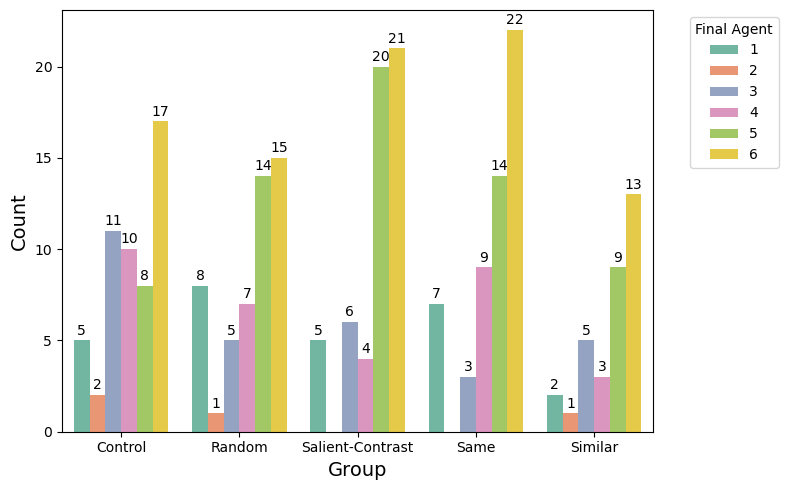

In [38]:
# Plot: Count of Final Agent by Group (with value labels on bars)
grouped = user_results.groupby(['group_label', 'final_agent']).size().reset_index(name='count')

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=grouped,
    x='group_label',
    y='count',
    hue='final_agent',
    palette='Set2'
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2, fontsize=10)

plt.legend(title='Final Agent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Group', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()

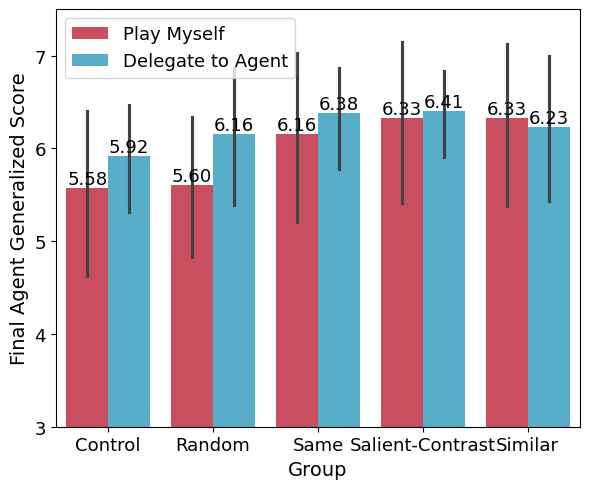


--- Same ---
 group_1  group_2     U      p
     0.0      1.0 315.5 0.4469

--- Similar ---
 group_1  group_2     U      p
     0.0      1.0 122.5 0.4533

--- Random ---
 group_1  group_2     U      p
     0.0      1.0 253.0 0.1267


In [39]:
# Plot: Final Agent Generalized Score by Group and Delegate
plot_barplot(user_results, 'group_label', 'final_agent_mean_score',
             y_label='Final Agent Generalized Score', hue='trust_the_agent',
             hue_names=['Play Myself', 'Delegate to Agent'],
             order=group_order,
             bar_label_fmt='%.2f', estimator='mean',
             palette=["#DC3A52", "#45B6DB"], ylim_bottom=3)

for grp in group_names:
    df_g = user_results[user_results['group_label'] == grp]
    if df_g['trust_the_agent'].nunique() > 1:
        print(f"\n--- {grp} ---")
        mannwhitneyu_test(df_g, 'final_agent_mean_score', 'trust_the_agent', test_type='less')

## Basic good choice

In [40]:
choices_results['group_label'].unique()

array(['Control', 'Random', 'Same', 'Similar', 'Contrast'], dtype=object)

In [41]:
choices_results['group_label'].value_counts()

group_label
Same        205
Contrast    198
Control     189
Random      185
Similar     116
Name: count, dtype: int64

In [42]:
user_results['group_label'].value_counts()

group_label
Salient-Contrast    56
Same                55
Control             53
Random              50
Similar             33
Name: count, dtype: int64

In [43]:
user_results['final_agent_mean_score'].value_counts()

final_agent_mean_score
7.8950    88
6.4750    65
5.7400    33
4.4875    30
2.5050    27
1.1900     4
Name: count, dtype: int64

In [44]:
user_results.columns
# user_choices['similarity_level'].value_counts()

Index(['user_id', 'group', 'group_label', 'trust_the_agent',
       'trust_explanations', 'evaluate_final_agent', 'tutorial_score', 'age',
       'gender', 'education', 'ai', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5',
       'Q205_1', 'Q205_3', 'Q205_4', 'Q205_5', 'Q205_6', 'final_agent',
       'number_of_choices', 'mean_feedback_count', 'mean_good_choice_local',
       'mean_good_choice_global', 'mean_good_choice_demo', 'mean_agent_rating',
       'final_score', 'final_agent_mean_score'],
      dtype='object')

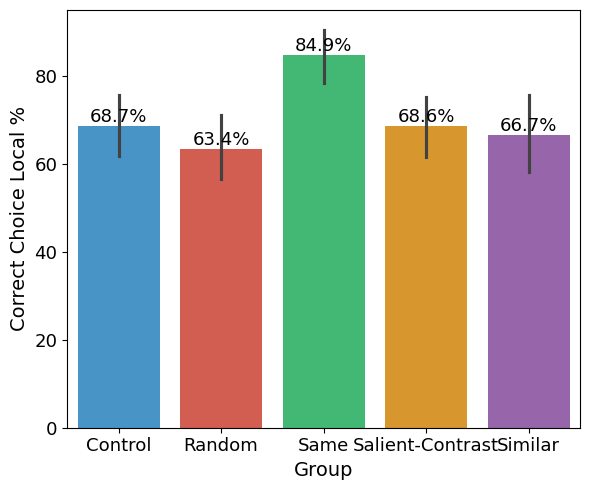

ANOVA F=5.5834, p=0.0003  |  Kruskal-Wallis H=22.3263, p=0.0002
         group_1          group_2      U      p
         Control           Random 1482.5 0.2944
         Control Salient-Contrast 1520.0 0.8266
         Control             Same  918.5 0.0005
         Control          Similar  924.5 0.6557
          Random Salient-Contrast 1271.0 0.4094
          Random             Same  738.0 0.0000
          Random          Similar  766.0 0.5821
Salient-Contrast             Same  993.5 0.0007
Salient-Contrast          Similar  948.5 0.8357
            Same          Similar 1280.5 0.0007


In [45]:
# Plot: Correct Choice (Local) by Group
plot_barplot(user_results, 'group_label', 'mean_good_choice_local',
             y_label='Correct Choice Local %', palette=colors_palette, order=group_order)
anova_test(user_results, 'mean_good_choice_local', 'group_label')
mannwhitneyu_test(user_results, 'mean_good_choice_local', 'group_label')

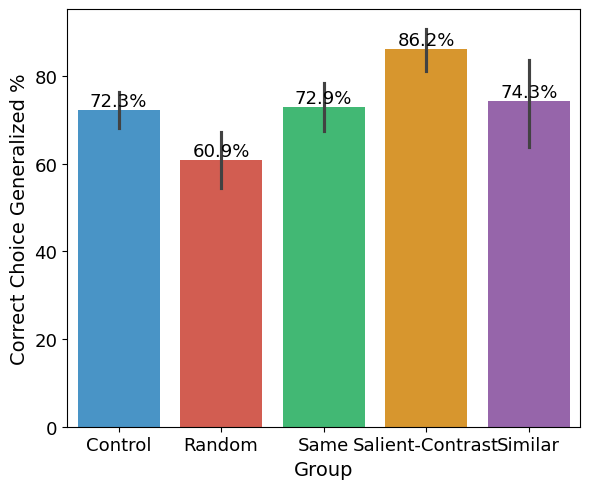

ANOVA F=9.4056, p=0.0000  |  Kruskal-Wallis H=34.5533, p=0.0000
         group_1          group_2      U      p
         Control           Random 1758.5 0.0037
         Control Salient-Contrast  818.0 0.0000
         Control             Same 1490.0 0.8415
         Control          Similar  739.0 0.2214
          Random Salient-Contrast  567.5 0.0000
          Random             Same  999.5 0.0146
          Random          Similar  564.5 0.0141
Salient-Contrast             Same 2095.0 0.0006
Salient-Contrast          Similar 1117.0 0.0745
            Same          Similar  828.0 0.4838


In [46]:
# Plot: Correct Choice (Generalized) by Group
plot_barplot(user_results, 'group_label', 'mean_good_choice_global',
             y_label='Correct Choice Generalized %', palette=colors_palette, order=group_order)
anova_test(user_results, 'mean_good_choice_global', 'group_label')
mannwhitneyu_test(user_results, 'mean_good_choice_global', 'group_label')

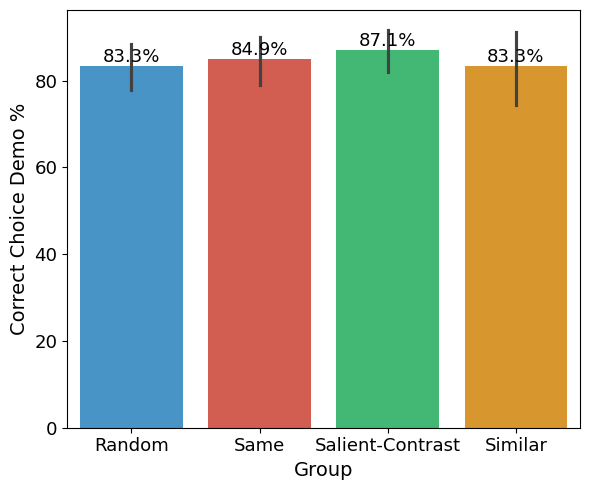

ANOVA F=0.3697, p=0.7750  |  Kruskal-Wallis H=1.2082, p=0.7510
         group_1          group_2      U      p
          Random Salient-Contrast 1245.0 0.2758
          Random             Same 1273.0 0.4692
          Random          Similar  777.0 0.6268
Salient-Contrast             Same 1583.5 0.7708
Salient-Contrast          Similar  966.5 0.6828
            Same          Similar  924.5 0.8711


In [47]:
# Plot: Correct Choice (demo) by Group
plot_df = user_results[user_results['group_label'] != 'Control']
plot_barplot(plot_df, 'group_label', 'mean_good_choice_demo', order=group_order[1:],
             y_label='Correct Choice Demo %', palette=colors_palette)
anova_test(plot_df, 'mean_good_choice_demo', 'group_label')
mannwhitneyu_test(plot_df, 'mean_good_choice_demo', 'group_label')

In [48]:
# choices_results[(choices_results['group_label'] == 'Same') & (choices_results['good_choice_demo'] == 0)][['user_id', 'episode_index', 'prev_agent', 'updated_agent', 'choice', 'demonstration_config', 'demonstration_level', 'demo_prev_score', 'demo_updated_score']]

In [49]:
def show_user_choices(user_id):
    return choices_results[choices_results['user_id'] == user_id]
show_user_choices('568708c6369319000c268f8d')

,user_id,episode_index,group,prev_agent,updated_agent,choice,good_choice_local,good_choice_global,good_choice_demo,feedback_config,...,demo_prev_score,demo_updated_score,feedback_count,feedback_correctness,agent_rating,trust_the_agent,choice_time,group_label,improved_from_prev_feedback,improved_from_prev_mean
136,568708c6369319000c268f8d,2,1,1,4,0,1,0,1,3,...,8.0,-3.0,1,0.0,5.0,0.0,125.0,Same,0,1
137,568708c6369319000c268f8d,3,1,1,3,1,0,1,0,1,...,6.0,-3.0,3,1.0,5.0,0.0,134.0,Same,0,1
138,568708c6369319000c268f8d,4,1,3,4,1,1,1,1,1,...,10.0,10.0,1,0.0,6.0,0.0,121.0,Same,0,1
139,568708c6369319000c268f8d,5,1,4,1,1,0,0,0,3,...,10.0,-3.0,3,0.0,5.0,0.0,120.0,Same,0,0


## Choice satisfaction

In [50]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'feedback_config', 'feedback_level', 'demonstration_config',
       'demonstration_level', 'demo_prev_score', 'demo_updated_score',
       'feedback_count', 'feedback_correctness', 'agent_rating',
       'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean'],
      dtype='object')

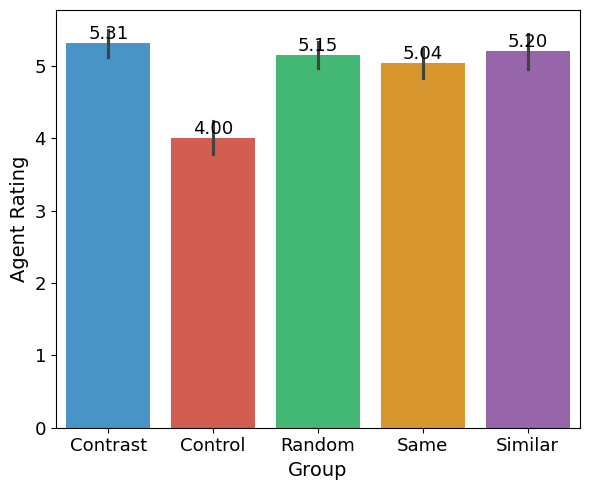

ANOVA F=28.2748, p=0.0000  |  Kruskal-Wallis H=85.1002, p=0.0000
 group_1 group_2       U      p
Contrast Control 27490.5 0.0000
Contrast  Random 19621.5 0.2126
Contrast    Same 22206.0 0.0922
Contrast Similar 11942.0 0.5434
 Control  Random 10284.5 0.0000
 Control    Same 12155.0 0.0000
 Control Similar  6345.0 0.0000
  Random    Same 19473.0 0.6368
  Random Similar 10441.5 0.6864
    Same Similar 11254.5 0.4143


In [51]:
# plot_barplot(choices_results[choices_results['group_label'] != 'Similar'], 'group_label', 'agent_rating', y_label='Agent Rating', palette=colors_palette,
#              bar_label_fmt='%.2f', estimator='mean')
# anova_test(choices_results[choices_results['group_label'] != 'Similar'], 'agent_rating', 'group_label')
# mannwhitneyu_test(choices_results[choices_results['group_label'] != 'Similar'], 'agent_rating', 'group_label', test_type='two-sided')

plot_barplot(choices_results, 'group_label', 'agent_rating', y_label='Agent Rating', palette=colors_palette,
             bar_label_fmt='%.2f', estimator='mean')
anova_test(choices_results, 'agent_rating', 'group_label')
mannwhitneyu_test(choices_results, 'agent_rating', 'group_label', test_type='two-sided')

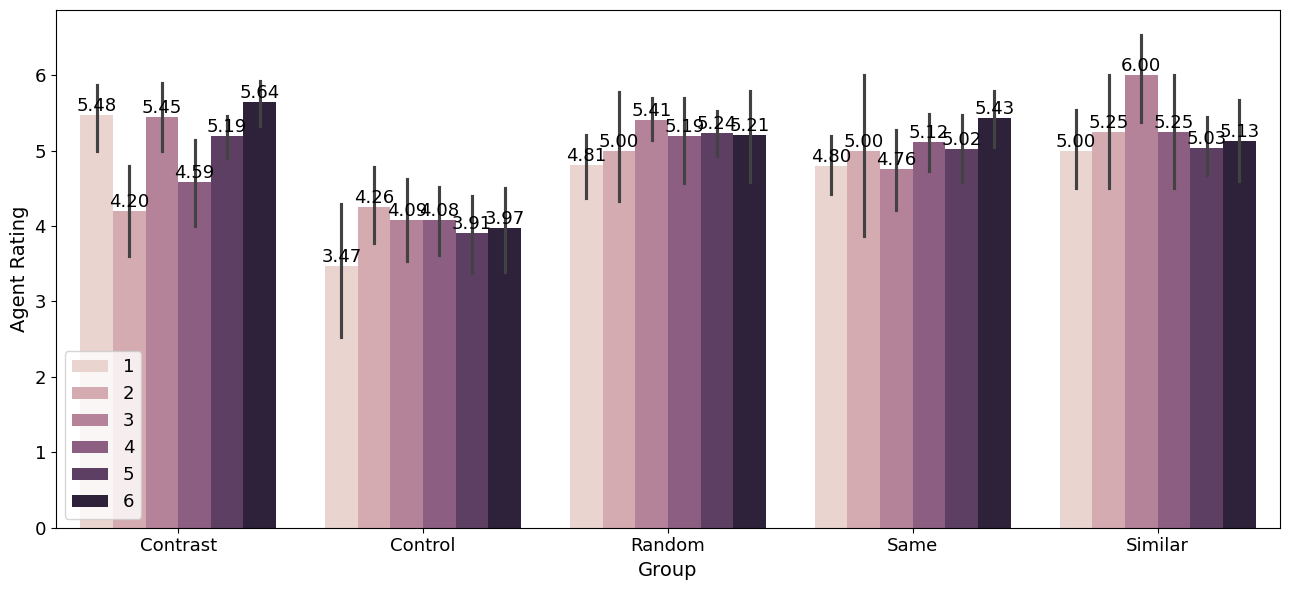

In [52]:
# Selected Agent
choices_results['selected_agent'] = choices_results.apply(lambda r: r['updated_agent'] if r['choice'] == 1 else r['prev_agent'], axis=1)
plot_barplot(choices_results, 'group_label', 'agent_rating', y_label='Agent Rating',
             hue='selected_agent',
             bar_label_fmt='%.2f', estimator='mean', figsize=(13,6))

In [53]:
import numpy as np
import pandas as pd
from scipy import stats

# Build selected agent per trial
choices_results = choices_results[choices_results['group_label'] != 'Similar'].copy()
choices_results['selected_agent'] = choices_results.apply(
    lambda r: r['updated_agent'] if r['choice'] == 1 else r['prev_agent'],
    axis=1
)

# Resolve selected-agent mean score robustly (handles key type mismatches)
def map_selected_agent_score(agent_name):
    if pd.isna(agent_name):
        return np.nan

    # 1) Try direct lookup in models_mean_dict
    if 'models_mean_dict' in globals() and isinstance(models_mean_dict, dict):
        if agent_name in models_mean_dict:
            return models_mean_dict[agent_name]

        # Try string/int conversions
        agent_as_str = str(agent_name)
        if agent_as_str in models_mean_dict:
            return models_mean_dict[agent_as_str]

        for k, v in models_mean_dict.items():
            if str(k) == agent_as_str:
                return v

    # 2) Fallback: if models_scores has an 'agent' column and score column
    if 'models_scores' in globals() and isinstance(models_scores, pd.DataFrame):
        candidate_score_cols = [
            'mean_score',
            'model_mean',
            'score',
            'agent_mean_score'
        ]

        if 'agent' in models_scores.columns:
            rows = models_scores[models_scores['agent'].astype(str) == str(agent_name)]
            if not rows.empty:
                for c in candidate_score_cols:
                    if c in rows.columns:
                        return rows[c].iloc[0]

    return np.nan

if isinstance(models_mean_scores, pd.DataFrame):
  agent_col = 'agent' if 'agent' in models_mean_scores.columns else 'agent_name'
  score_col = next(
    (c for c in ['mean_score', 'model_mean', 'score', 'agent_mean_score'] if c in models_mean_scores.columns),
    None
  )
  if score_col is None:
    raise ValueError("models_mean_scores must contain a score column.")

  agent_score_map = (
    models_mean_scores[[agent_col, score_col]]
    .dropna()
    .assign(**{agent_col: lambda d: d[agent_col].astype(str)})
    .drop_duplicates(subset=[agent_col])
    .set_index(agent_col)[score_col]
  )
else:
  agent_score_map = pd.Series(models_mean_scores)
  agent_score_map.index = agent_score_map.index.astype(str)

choices_results['selected_agent_mean_score'] = choices_results['selected_agent'].astype(str).map(agent_score_map)

# Keep only rows with the two variables needed for correlation
corr_df = choices_results[['group_label', 'agent_rating', 'selected_agent_mean_score']].dropna()

if corr_df.empty:
    print('No rows available after removing missing values for correlation analysis.')
    print('Diagnostics:')
    print(f"total rows in choices_results: {len(choices_results)}")
    print(f"rows with non-null agent_rating: {choices_results['agent_rating'].notna().sum()}")
    print(f"rows with non-null selected_agent_mean_score: {choices_results['selected_agent_mean_score'].notna().sum()}")
else:
    # Overall correlation (all groups together)
    pearson_all = stats.pearsonr(corr_df['agent_rating'], corr_df['selected_agent_mean_score'])
    spearman_all = stats.spearmanr(corr_df['agent_rating'], corr_df['selected_agent_mean_score'])

    print('Overall correlation (all groups):')
    print(f"Pearson r = {pearson_all.statistic:.3f}, p = {pearson_all.pvalue:.4g}")
    print(f"Spearman rho = {spearman_all.statistic:.3f}, p = {spearman_all.pvalue:.4g}")

    def compute_group_corr(group_df: pd.DataFrame) -> pd.Series:
        x = group_df['agent_rating']
        y = group_df['selected_agent_mean_score']
        n = len(group_df)

        # Need at least 3 points and some variance in both variables
        if n < 3 or x.nunique() < 2 or y.nunique() < 2:
            return pd.Series({
                'n': n,
                'pearson_r': np.nan,
                'pearson_p': np.nan,
                'spearman_rho': np.nan,
                'spearman_p': np.nan
            })

        pearson = stats.pearsonr(x, y)
        spearman = stats.spearmanr(x, y)

        return pd.Series({
            'n': n,
            'pearson_r': pearson.statistic,
            'pearson_p': pearson.pvalue,
            'spearman_rho': spearman.statistic,
            'spearman_p': spearman.pvalue
        })

    # Correlation per group
    corr_by_group = (
        corr_df
        .groupby('group_label', as_index=True)
        .apply(compute_group_corr)
        .reset_index()
    )

    # Optional ordering if group_names exists
    if 'group_names' in globals():
        corr_by_group['group_label'] = pd.Categorical(
            corr_by_group['group_label'],
            categories=group_names,
            ordered=True
        )
        corr_by_group = corr_by_group.sort_values('group_label')

    print('\nCorrelation by group:')
    display(corr_by_group)

    # Simple comparison metrics across groups
    valid_groups = corr_by_group.dropna(subset=['pearson_r', 'spearman_rho']).copy()
    if len(valid_groups) >= 2:
        strongest_pearson = valid_groups.loc[valid_groups['pearson_r'].abs().idxmax()]
        strongest_spearman = valid_groups.loc[valid_groups['spearman_rho'].abs().idxmax()]

        print('\nGroup comparison summary:')
        print(
            f"Strongest |Pearson r|: {strongest_pearson['group_label']} "
            f"({strongest_pearson['pearson_r']:.3f})"
        )
        print(
            f"Strongest |Spearman rho|: {strongest_spearman['group_label']} "
            f"({strongest_spearman['spearman_rho']:.3f})"
        )
    else:
        print('\nNot enough valid groups to compare correlation strength.')

Overall correlation (all groups):
Pearson r = 0.101, p = 0.004998
Spearman rho = 0.121, p = 0.0007578

Correlation by group:


,group_label,n,pearson_r,pearson_p,spearman_rho,spearman_p
3,Same,205.0,0.137382,0.049494,0.156911,0.024651
0,Contrast,198.0,0.101896,0.153164,0.150130,0.034762
2,Random,185.0,0.101856,0.167714,0.114131,0.121891
1,NaN,189.0,-0.016616,0.820471,-0.014799,0.839826



Group comparison summary:
Strongest |Pearson r|: Same (0.137)
Strongest |Spearman rho|: Same (0.157)


## Choice Time

In [54]:
choices_results[(choices_results['choice_time'] >60)]#['choice_time'].value_counts()

,user_id,episode_index,group,prev_agent,updated_agent,choice,good_choice_local,good_choice_global,good_choice_demo,feedback_config,...,feedback_count,feedback_correctness,agent_rating,trust_the_agent,choice_time,group_label,improved_from_prev_feedback,improved_from_prev_mean,selected_agent,selected_agent_mean_score
77,6997ab9f698c60b50beaba59,1,4,1,5,0,1,0,1,2,...,18,8.0,6.0,1.0,121.0,Random,0,1,1,2.5050
80,6997ab9f698c60b50beaba59,4,4,3,6,0,0,0,1,1,...,67,36.0,7.0,1.0,65.0,Random,1,1,3,4.4875
111,698c054ad44c45a1061327b9,4,3,5,4,0,0,1,1,3,...,26,11.0,3.0,1.0,75.0,Contrast,1,0,5,6.4750
136,568708c6369319000c268f8d,2,1,1,4,0,1,0,1,3,...,1,0.0,5.0,0.0,125.0,Same,0,1,1,2.5050
137,568708c6369319000c268f8d,3,1,1,3,1,0,1,0,1,...,3,1.0,5.0,0.0,134.0,Same,0,1,3,4.4875
138,568708c6369319000c268f8d,4,1,3,4,1,1,1,1,1,...,1,0.0,6.0,0.0,121.0,Same,0,1,4,5.7400
139,568708c6369319000c268f8d,5,1,4,1,1,0,0,0,3,...,3,0.0,5.0,0.0,120.0,Same,0,0,1,2.5050
303,68ca863ee90ab337a8422bff,5,1,4,1,1,1,0,1,1,...,2,0.0,5.0,1.0,95.0,Same,1,0,1,2.5050
520,673e222bdb1a35935b3075f1,1,4,1,5,1,1,1,1,3,...,1,1.0,6.0,0.0,9695.0,Random,1,1,5,6.4750
521,673e222bdb1a35935b3075f1,2,4,5,2,1,0,0,0,0,...,4,2.0,7.0,0.0,9693.0,Random,0,0,2,1.1900


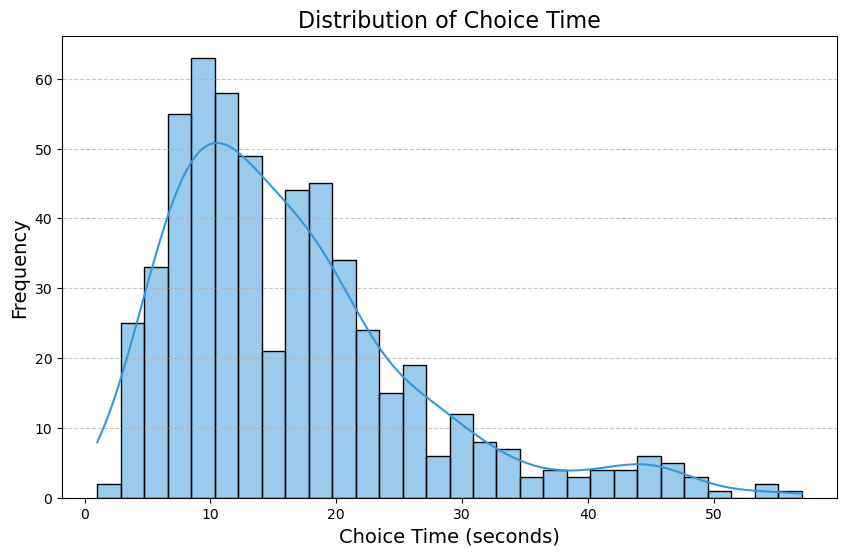

count    556.000000
mean      16.523381
std       10.090643
min        1.000000
25%        9.000000
50%       14.000000
75%       21.000000
max       57.000000
Name: choice_time, dtype: float64

In [55]:
plt.figure(figsize=(10, 6))
plot_df = choices_results[(choices_results['choice_time'] < 60) & (choices_results['choice_time'] > 0)]  # Filter out extreme outliers for better visualization

sns.histplot(plot_df['choice_time'], kde=True, color='#3498db', bins=30)
plt.title('Distribution of Choice Time', fontsize=16)
plt.xlabel('Choice Time (seconds)', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plot_df['choice_time'].describe()

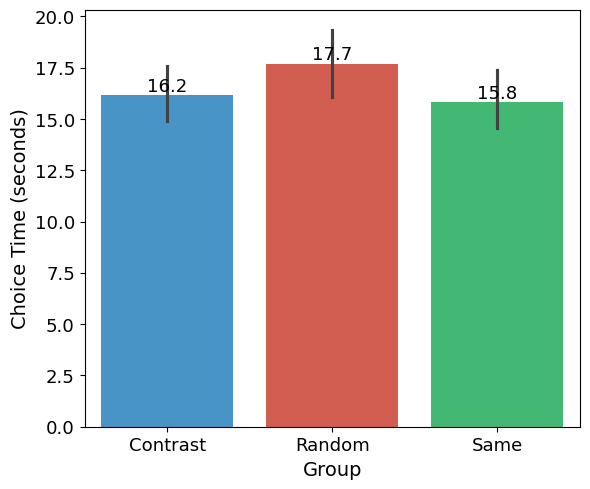

ANOVA F=1.7603, p=0.1729  |  Kruskal-Wallis H=1.9088, p=0.3850
 group_1 group_2       U      p
Contrast  Random 15959.0 0.5254
Contrast    Same 19261.5 0.4452
  Random    Same 17800.0 0.1685


In [56]:
plot_df = choices_results[(choices_results['choice_time'] < 60) & (choices_results['choice_time'] > 0)]  # Filter out extreme outliers for better visualization
if plot_df.empty:
    print("No valid choice_time data to plot.")
else:
    plot_barplot(plot_df, 'group_label', 'choice_time', y_label='Choice Time (seconds)', palette=colors_palette,
             bar_label_fmt='%.1f', estimator='mean')
    anova_test(plot_df, 'choice_time', 'group_label')
    mannwhitneyu_test(plot_df, 'choice_time', 'group_label')

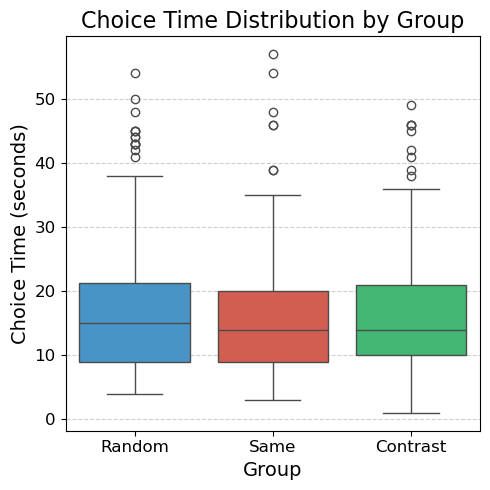

 group_1 group_2      U      p
Contrast  Random 1205.0 0.3664
Contrast    Same 1560.0 0.6470
  Random    Same 1481.5 0.1552
group_label  n_users  mean_choice_time
     Random       48         18.102431
       Same       53         15.974214
   Contrast       56         15.966369


In [57]:
plt.figure(figsize=(5, 5))

# Normalize group naming to avoid NaN categories (e.g., Salient-Contrast -> Contrast)
plot_df = plot_df.copy()
plot_df['group_label'] = plot_df['group_label'].replace({'Salient-Contrast': 'Contrast'})

sns.boxplot(data=plot_df, x='group_label', y='choice_time', palette=colors_palette)

plt.title('Choice Time Distribution by Group', fontsize=16)
plt.xlabel('Group', fontsize=14)
plt.ylabel('Choice Time (seconds)', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Mean choice time per user
user_mean_choice_time = (
    plot_df.groupby(['group_label', 'user_id'], as_index=False)['choice_time']
    .mean()
    .rename(columns={'choice_time': 'mean_choice_time'})
)

# Mann-Whitney should be run on user-level means (between-user comparison)
mannwhitneyu_test(user_mean_choice_time, 'mean_choice_time', 'group_label', test_type='two-sided')

# For each group: number of users + mean of users' mean choice time
group_choice_time_summary = (
    user_mean_choice_time.groupby('group_label', as_index=False)
    .agg(
        n_users=('user_id', 'nunique'),
        mean_choice_time=('mean_choice_time', 'mean')
    )
)

if 'group_order' in globals():
    local_group_order = [
        'Contrast' if g == 'Salient-Contrast' else g
        for g in group_order
    ]
    local_group_order = list(dict.fromkeys(local_group_order))

    group_choice_time_summary['group_label'] = pd.Categorical(
        group_choice_time_summary['group_label'],
        categories=local_group_order,
        ordered=True
    )
    group_choice_time_summary = group_choice_time_summary.sort_values('group_label')

print(group_choice_time_summary.to_string(index=False))


## Good choice by update direction

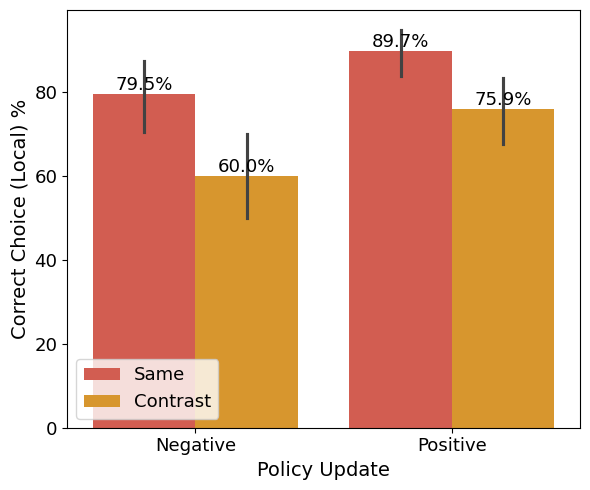

--- Positive updates ---
 group_1 group_2      U      p
Contrast    Same 5445.0 0.0058
--- Negative updates ---
 group_1 group_2      U      p
Contrast    Same 3186.0 0.0047


In [58]:
# Plot: Correct Choice (Local) by Update Direction — Same vs Contrast
plot_df = choices_results[choices_results['group_label'].isin(['Same', 'Contrast'])].copy()
plot_barplot(plot_df, 'improved_from_prev_feedback', 'good_choice_local',
             y_label='Correct Choice (Local) %', x_label='Policy Update',
             x_val_names=['Negative', 'Positive'], hue='group_label',
             palette=[ '#e74c3c', '#f39c12'])
print("--- Positive updates ---")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback']==1], 'good_choice_local', 'group_label')
print("--- Negative updates ---")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_feedback']==0], 'good_choice_local', 'group_label')

In [59]:
choices_results.groupby(['group_label', 'improved_from_prev_feedback'])['good_choice_local'].mean()

group_label  improved_from_prev_feedback
Contrast     0                              0.600000
             1                              0.759259
Control      0                              0.233766
             1                              1.000000
Random       0                              0.588235
             1                              0.632479
Same         0                              0.795455
             1                              0.897436
Name: good_choice_local, dtype: float64

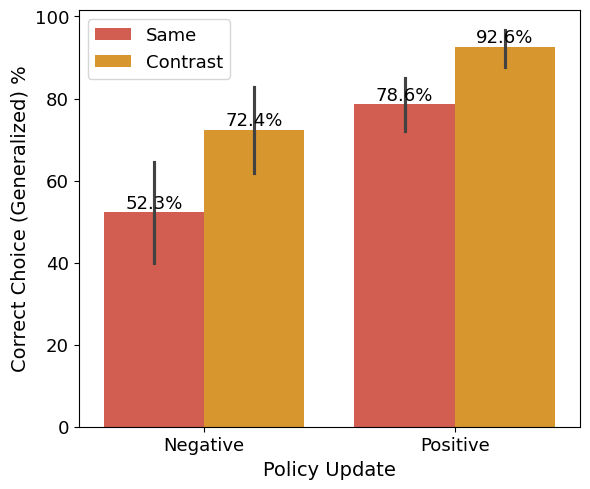

--- Positive updates ---
 group_1 group_2      U      p
Contrast    Same 9740.0 0.0015
--- Negative updates ---
 group_1 group_2      U      p
Contrast    Same 2965.5 0.0143


In [60]:
# Plot: Correct Choice (Generalized) by Update Direction — Same vs Contrast
plot_df = choices_results[choices_results['group_label'].isin(['Same', 'Contrast'])].copy()
plot_barplot(plot_df, 'improved_from_prev_mean', 'good_choice_global',
             y_label='Correct Choice (Generalized) %', x_label='Policy Update',
             x_val_names=['Negative', 'Positive'], hue='group_label',
             palette=[ '#e74c3c', '#f39c12', '#e74c3c', '#3498db'])
print("--- Positive updates ---")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean']==1], 'good_choice_global', 'group_label')
print("--- Negative updates ---")
mannwhitneyu_test(plot_df[plot_df['improved_from_prev_mean']==0], 'good_choice_global', 'group_label')

## Trust and delegaction

In [61]:
user_results['trust_the_agent'].value_counts()

trust_the_agent
1.0    152
0.0     94
Name: count, dtype: int64

In [62]:
explanations = user_results[user_results['group'] == 1]['trust_explanations']
for exp in explanations:
    print(f"- {exp}")

- I am eager to see how it would perform now 
- I think they may do a better job at being strategic about the game, based on what I saw in previous rounds. 
- It did very well
- I'm rubbish!
- I then have control over the outcome, otherwise it could be chance.
- I am meant to train the AI agent
- the AI agent plays better
- I did a better job on the last round and one of other rounds, so overall maybe I did a little bit better but not certain. Just pick my own why not.
- because I have already trained it and expect it to perform better
- I felt AI has a lot of unnecessary movements that puts it into worse positions for the upcoming objectives. 
- I can play better than the AI agent i trained.
- I think the AI agent has more control
- I think it was hard to control the AI agent to complete a perfect game and would trust myself more at this stage. 
- I felt AI was performing quite well
- I think the AI is better
- We were not far apart in ability, plus now that i updated it and its train

In [63]:
user_results.columns

Index(['user_id', 'group', 'group_label', 'trust_the_agent',
       'trust_explanations', 'evaluate_final_agent', 'tutorial_score', 'age',
       'gender', 'education', 'ai', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5',
       'Q205_1', 'Q205_3', 'Q205_4', 'Q205_5', 'Q205_6', 'final_agent',
       'number_of_choices', 'mean_feedback_count', 'mean_good_choice_local',
       'mean_good_choice_global', 'mean_good_choice_demo', 'mean_agent_rating',
       'final_score', 'final_agent_mean_score'],
      dtype='object')

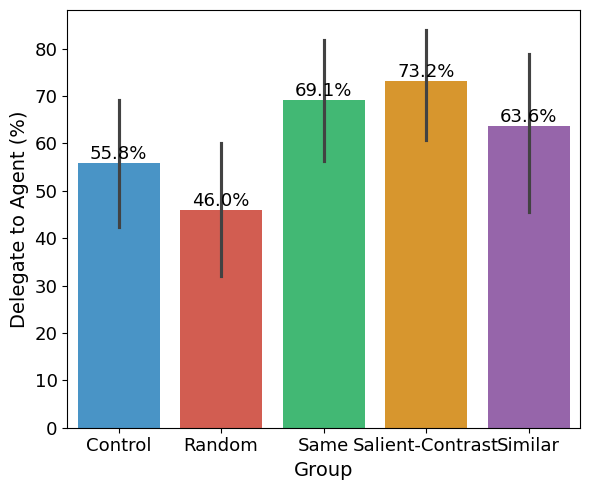

ANOVA F=2.6765, p=0.0325  |  Kruskal-Wallis H=10.4208, p=0.0339
         group_1          group_2      U      p
         Control           Random 1427.0 0.1641
         Control Salient-Contrast 1202.0 0.9707
         Control             Same 1239.5 0.9223
         Control          Similar  790.5 0.7640
          Random Salient-Contrast 1019.0 0.9978
          Random             Same 1057.5 0.9915
          Random          Similar  679.5 0.9420
Salient-Contrast             Same 1603.5 0.3179
Salient-Contrast          Similar 1012.5 0.1739
            Same          Similar  957.0 0.3020


In [64]:
# Plot: Trust the Agent by Group
plot_barplot(user_results, 'group_label', 'trust_the_agent',
             y_label='Delegate to Agent (%)', palette=colors_palette, order=group_order)
anova_test(user_results, 'trust_the_agent', 'group_label')
mannwhitneyu_test(user_results, 'trust_the_agent', 'group_label', test_type='greater')

In [65]:
user_results.columns

Index(['user_id', 'group', 'group_label', 'trust_the_agent',
       'trust_explanations', 'evaluate_final_agent', 'tutorial_score', 'age',
       'gender', 'education', 'ai', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5',
       'Q205_1', 'Q205_3', 'Q205_4', 'Q205_5', 'Q205_6', 'final_agent',
       'number_of_choices', 'mean_feedback_count', 'mean_good_choice_local',
       'mean_good_choice_global', 'mean_good_choice_demo', 'mean_agent_rating',
       'final_score', 'final_agent_mean_score'],
      dtype='object')

In [66]:
user_results[user_results['final_agent'] == 6]['group_label'].value_counts()

group_label
Same                22
Salient-Contrast    21
Control             17
Random              15
Similar             13
Name: count, dtype: int64

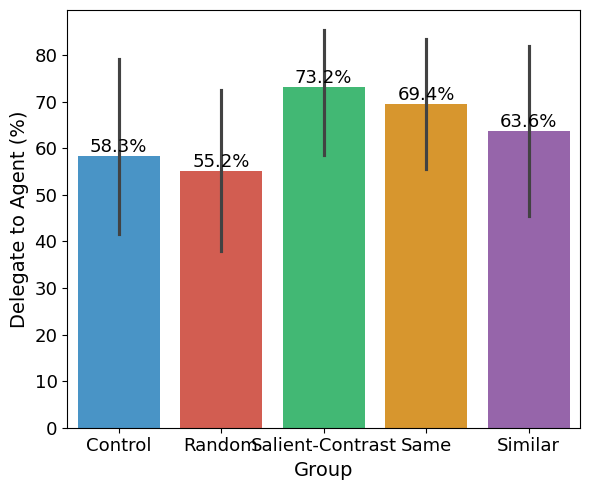

ANOVA F=2.6765, p=0.0325  |  Kruskal-Wallis H=10.4208, p=0.0339
         group_1          group_2      U      p
         Control           Random 1427.0 0.8379
         Control Salient-Contrast 1202.0 0.0298
         Control             Same 1239.5 0.0788
         Control          Similar  790.5 0.2393
          Random Salient-Contrast 1019.0 0.0022
          Random             Same 1057.5 0.0087
          Random          Similar  679.5 0.0593
Salient-Contrast             Same 1603.5 0.6848
Salient-Contrast          Similar 1012.5 0.8288
            Same          Similar  957.0 0.7017


In [67]:
# Plot: Delegate to Agent by Group (only users that ended with agent 6)
plot_barplot(user_results[(user_results['final_agent'] == 6) | (user_results['final_agent'] == 5)], 'group_label', 'trust_the_agent',
             y_label='Delegate to Agent (%)', palette=colors_palette)
anova_test(user_results, 'trust_the_agent', 'group_label')
mannwhitneyu_test(user_results, 'trust_the_agent', 'group_label', test_type='less')

## Satisfactions and Rating

In [68]:
user_results.columns

Index(['user_id', 'group', 'group_label', 'trust_the_agent',
       'trust_explanations', 'evaluate_final_agent', 'tutorial_score', 'age',
       'gender', 'education', 'ai', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5',
       'Q205_1', 'Q205_3', 'Q205_4', 'Q205_5', 'Q205_6', 'final_agent',
       'number_of_choices', 'mean_feedback_count', 'mean_good_choice_local',
       'mean_good_choice_global', 'mean_good_choice_demo', 'mean_agent_rating',
       'final_score', 'final_agent_mean_score'],
      dtype='object')

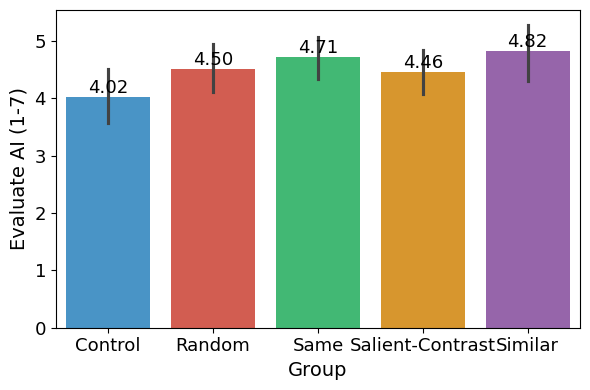

ANOVA F=1.8184, p=0.1259  |  Kruskal-Wallis H=5.9054, p=0.2063
         group_1          group_2      U      p
         Control           Random 1124.5 0.1794
         Control Salient-Contrast 1271.0 0.1895
         Control             Same 1140.5 0.0474
         Control          Similar  653.5 0.0458
          Random Salient-Contrast 1410.5 0.9484
          Random             Same 1273.0 0.5050
          Random          Similar  730.0 0.3673
Salient-Contrast             Same 1405.5 0.4178
Salient-Contrast          Similar  802.5 0.2911
            Same          Similar  864.5 0.7059


In [69]:
# after the game evaluation of the agent's performance

plot_barplot(user_results, 'group_label', 'evaluate_final_agent', y_label='Evaluate AI (1-7)', estimator='mean', palette=colors_palette, 
             order=group_order, 
             bar_label_fmt='%.2f',
             figsize=(6,4))
anova_test(user_results, 'evaluate_final_agent', 'group_label')
mannwhitneyu_test(user_results, 'evaluate_final_agent', 'group_label', test_type='two-sided')

In [70]:
# Calculate user_satisfaction = mean(Q205_1 - Q205_3 + Q205_4 + Q205_5 + Q205_6)
# Q205_1: explanations clear and easy to understand (positive)
# Q205_3: explanations too detailed and overwhelming (negative - subtract)
# Q205_4: explanations helped see feedback changes (positive)
# Q205_5: visual demonstrations helped understand differences (positive)
# Q205_6: feedback helped improve agent's performance (positive)

user_question_mapping = {
    'Q205_1': "The explanations of the agent's paths were clear and easy to understand",
    'Q205_3': "The explanations felt too detailed and overwhelming",
    'Q205_4': "The explanations helped me see how my feedback changed the agent's behavior",
    'Q205_5':"The visual demonstrations of policy changes helped me understand the differences between agents",
    'Q205_6': "My feedback helped improve the agent's performance",
    "ai:": "How familiar are you with Artificial Intelligence?",
    "AI_1": "I believe AI will improve my life",
    "AI_2": "I believe that AI will improve my work",
    "AI_3": "I think I will use AI technology in the future",
    "AI_4": "I think AI technology is a threat to humans",
    "AI_5": "I think AI technology is positive for humanity",
    "user_satisfaction": "User Overall Satisfaction Score"
}


user_results_sat = user_results.copy()

# Convert columns to numeric, handling any non-numeric values
satisfaction_cols = ['Q205_1', 'Q205_3', 'Q205_4', 'Q205_5', 'Q205_6']
for col in satisfaction_cols:
    user_results_sat[col] = pd.to_numeric(user_results_sat[col], errors='coerce')

# Calculate satisfaction score
user_results_sat['user_satisfaction'] = (
    user_results_sat['Q205_1'] - 
    user_results_sat['Q205_3'] + 
    user_results_sat['Q205_4'] + 
    user_results_sat['Q205_5'] + 
    user_results_sat['Q205_6']
) / 5  # Divide by 5 to get the mean

# Display statistics
print("User Satisfaction by Group:")
print(user_results_sat.groupby('group_label')['user_satisfaction'].describe())
print(f"\nOverall Mean Satisfaction: {user_results_sat['user_satisfaction'].mean():.2f}")
print(f"Overall Std Satisfaction: {user_results_sat['user_satisfaction'].std():.2f}")

# Save updated results
user_results_sat.to_csv('user_final_results.csv', index=False)
user_results = user_results_sat.copy()  # Update the main dataframe

User Satisfaction by Group:
                  count      mean       std  min  25%  50%  75%  max
group_label                                                         
Control             0.0       NaN       NaN  NaN  NaN  NaN  NaN  NaN
Random             50.0  3.392000  1.029333  0.8  2.6  3.7  4.2  5.2
Salient-Contrast   56.0  3.475000  1.023052  1.0  2.8  3.7  4.2  5.2
Same               55.0  3.516364  0.951172  0.4  3.2  3.6  4.2  5.0
Similar            33.0  3.157576  1.176603 -0.2  2.6  3.2  3.8  5.4

Overall Mean Satisfaction: 3.41
Overall Std Satisfaction: 1.03


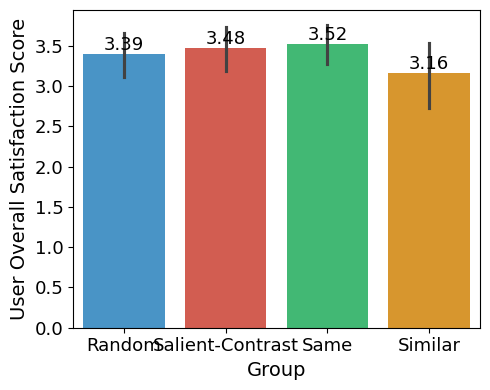


--- Statistical Tests for User Satisfaction ---
ANOVA F=0.9306, p=0.4270  |  Kruskal-Wallis H=2.3974, p=0.4941
         group_1          group_2      U      p
          Random Salient-Contrast 1347.0 0.7390
          Random             Same 1290.0 0.5866
          Random          Similar  926.5 0.3460
Salient-Contrast             Same 1518.0 0.8988
Salient-Contrast          Similar 1072.0 0.2091
            Same          Similar 1083.0 0.1303


In [71]:
# Plot: User Satisfaction by Group
plot_df = user_results[user_results['group_label'] != 'Control']
column = 'user_satisfaction' #'Q205_5'
plot_barplot(plot_df, 'group_label', column,
             y_label=user_question_mapping[column], palette=colors_palette,
             estimator='mean', bar_label_fmt='%.2f', figsize=(5,4),
             ylim_bottom=0)

# Statistical tests
print("\n--- Statistical Tests for User Satisfaction ---")
anova_test(plot_df, column, 'group_label')
mannwhitneyu_test(plot_df, column, 'group_label', test_type='two-sided')

In [72]:
choices_results.columns

Index(['user_id', 'episode_index', 'group', 'prev_agent', 'updated_agent',
       'choice', 'good_choice_local', 'good_choice_global', 'good_choice_demo',
       'feedback_config', 'feedback_level', 'demonstration_config',
       'demonstration_level', 'demo_prev_score', 'demo_updated_score',
       'feedback_count', 'feedback_correctness', 'agent_rating',
       'trust_the_agent', 'choice_time', 'group_label',
       'improved_from_prev_feedback', 'improved_from_prev_mean',
       'selected_agent', 'selected_agent_mean_score'],
      dtype='object')

In [73]:
choices_results.head(2)

,user_id,episode_index,group,prev_agent,updated_agent,choice,good_choice_local,good_choice_global,good_choice_demo,feedback_config,...,feedback_count,feedback_correctness,agent_rating,trust_the_agent,choice_time,group_label,improved_from_prev_feedback,improved_from_prev_mean,selected_agent,selected_agent_mean_score
0,69b03531db81dab44c5b09a4,1,0,1,2,1,0,0,0,2,...,5,1.0,5.0,1.0,0.0,Control,0,0,2,1.190
1,69b03531db81dab44c5b09a4,5,0,2,1,1,1,1,0,2,...,8,2.0,3.0,1.0,0.0,Control,1,1,1,2.505


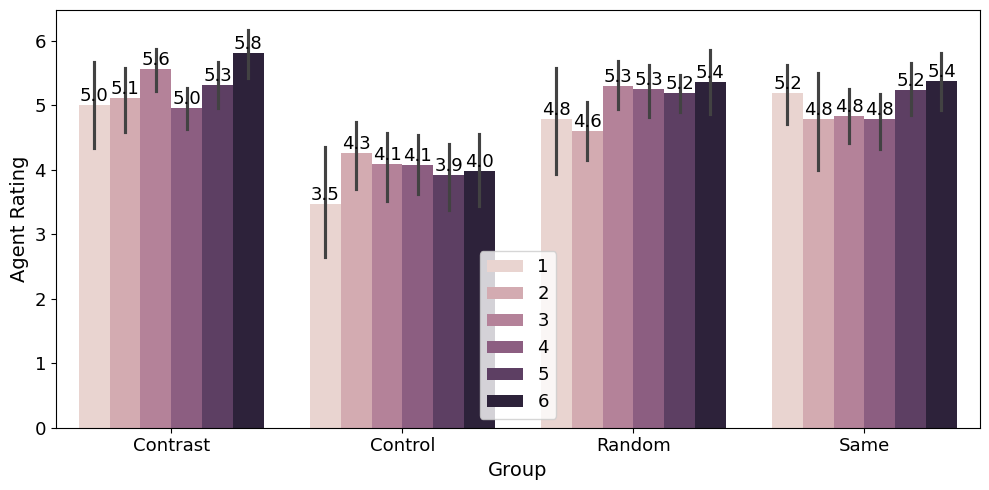

In [74]:
# agent rating by group
plot_barplot(choices_results, 'group_label', 'agent_rating', hue='updated_agent', figsize=(10, 5),
             y_label='Agent Rating',
             estimator=lambda x: np.mean(x), bar_label_fmt='%.1f')

## More plots

In [75]:
user_results.columns

Index(['user_id', 'group', 'group_label', 'trust_the_agent',
       'trust_explanations', 'evaluate_final_agent', 'tutorial_score', 'age',
       'gender', 'education', 'ai', 'AI_1', 'AI_2', 'AI_3', 'AI_4', 'AI_5',
       'Q205_1', 'Q205_3', 'Q205_4', 'Q205_5', 'Q205_6', 'final_agent',
       'number_of_choices', 'mean_feedback_count', 'mean_good_choice_local',
       'mean_good_choice_global', 'mean_good_choice_demo', 'mean_agent_rating',
       'final_score', 'final_agent_mean_score', 'user_satisfaction'],
      dtype='object')

#### Analyze agent changes on specific boards

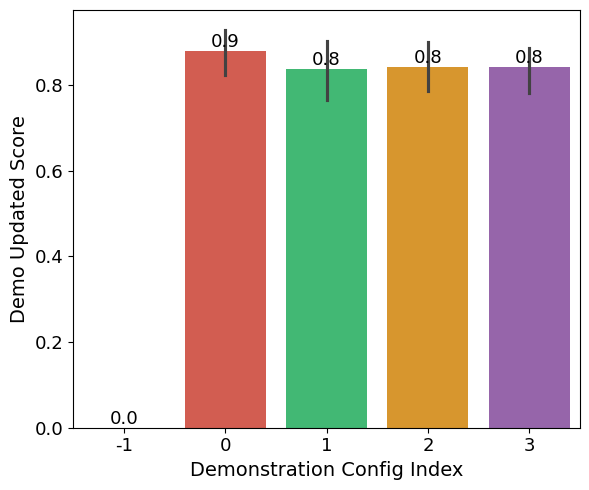

In [76]:
# demo score vs config_idx
plot_barplot(choices_results, 'demonstration_config', 'good_choice_demo',
             y_label='Demo Updated Score', palette=colors_palette, x_label='Demonstration Config Index',
             estimator='mean', bar_label_fmt='%.1f')

In [77]:
choices_results.columns
choices_results['demo_score_diff'] = choices_results['demo_updated_score'] - choices_results['demo_prev_score']
# Bin demo diff into unit-width ranges: 0-1, 1-2, 2-3, ...
choices_results['demo_score_diff_abs'] = choices_results['demo_score_diff'].abs()

max_edge = int(np.ceil(choices_results['demo_score_diff_abs'].max()))
bin_edges = np.arange(0, max_edge + 1, 1)

if len(bin_edges) < 2:
    bin_edges = np.array([0, 1])

# Use Python list for bins (avoids type issues with ndarray in pd.cut stubs)
base_edges = [float(x) for x in bin_edges.tolist()]

# Count items in each unit-width bin first
unit_bin_idx = pd.cut(
    choices_results['demo_score_diff_abs'],
    bins=base_edges,
    include_lowest=True,
    right=False,
    labels=False
)

unit_counts = (
    pd.Series(unit_bin_idx)
    .value_counts(dropna=True)
    .reindex(range(len(base_edges) - 1), fill_value=0)
    .to_numpy()
)

# Merge consecutive bins so each merged bin has at least 10 items (when possible)
merged_edges = [base_edges[0]]
running = 0

for i, c in enumerate(unit_counts):
    running += int(c)
    is_last = i == len(unit_counts) - 1

    if running >= 10:
        merged_edges.append(base_edges[i + 1])
        running = 0
    elif is_last:
        # leftover tail (<10) has no "next" bin, so extend previous merged bin to the end
        if merged_edges[-1] != base_edges[-1]:
            merged_edges.append(base_edges[-1])

# Safety: ensure valid bin edges for pd.cut
if len(merged_edges) < 2:
    merged_edges = [base_edges[0], base_edges[-1] if base_edges[-1] > base_edges[0] else base_edges[0] + 1.0]

bin_labels = [
    f"{int(merged_edges[i])}-{int(merged_edges[i + 1])}"
    for i in range(len(merged_edges) - 1)
]

choices_results['demo_score_diff_bin'] = pd.cut(
    choices_results['demo_score_diff_abs'],
    bins=merged_edges,
    labels=bin_labels,
    include_lowest=True,
    right=False
)

choices_results['demo_score_diff_bin'].value_counts(sort=False)

demo_score_diff_bin
0-1      49
1-2      77
2-3      60
3-4      39
4-5      41
5-6      28
6-7      29
7-10     27
10-12    21
12-13    23
13-14    23
14-15    40
15-16    39
16-17    33
17-18    15
18-19    13
19-20    14
Name: count, dtype: int64

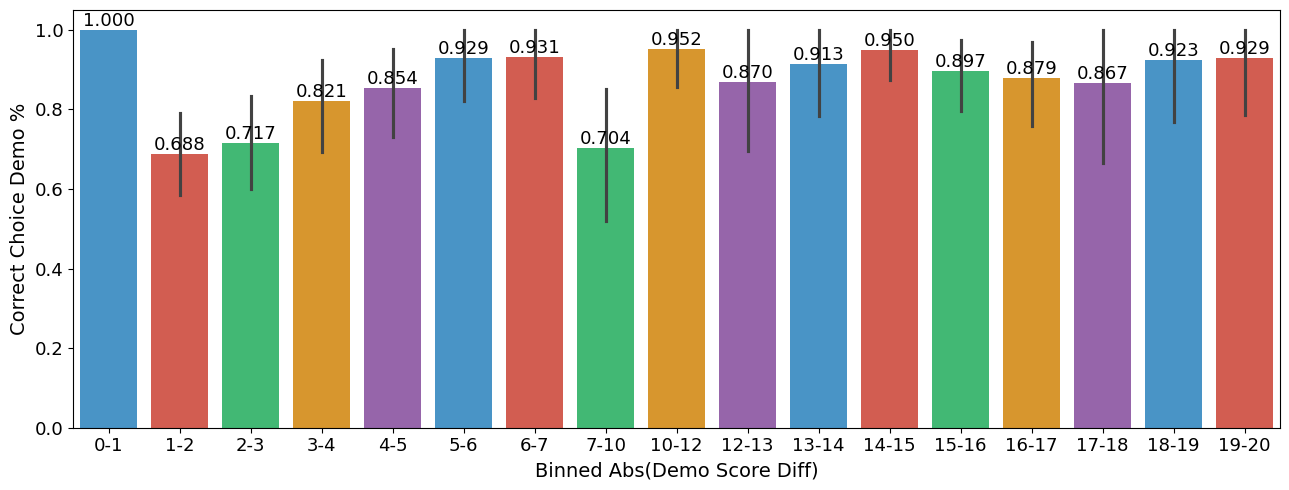

In [78]:
# demo correct choice vs demo score diff bin
plot_barplot(choices_results[choices_results['demo_score_diff_bin'].notnull()], 'demo_score_diff_bin', 'good_choice_demo',
             y_label='Correct Choice Demo %', palette=colors_palette, x_label='Binned Abs(Demo Score Diff)',
             estimator='mean', bar_label_fmt='%.3f', figsize=(13, 5), order=bin_labels)

In [79]:
# number of choices where good_choice_local != good_choice_global
num_diff = choices_results[choices_results["good_choice_demo"] != choices_results["good_choice_global"]].shape[0]
print(num_diff)

248


In [80]:
user_results.groupby('group_label')['number_of_choices'].describe()

,count,mean,std,min,25%,50%,75%,max
group_label,,,,,,,,
Control,53.0,3.566038,1.118196,1.0,3.0,4.0,4.0,5.0
Random,50.0,3.700000,0.931315,2.0,3.0,4.0,4.0,5.0
Salient-Contrast,56.0,3.535714,1.094852,1.0,3.0,4.0,4.0,5.0
Same,55.0,3.727273,1.079344,1.0,3.0,4.0,5.0,5.0
Similar,33.0,3.515152,0.905580,2.0,3.0,3.0,4.0,5.0


## Statistic Tests

In [81]:
# ── 1. USER-LEVEL AGGREGATED TESTS ──────────────────────────────────
# Aggregate to one row per user (proper unit of analysis for between-subjects design)
from scipy.stats import mannwhitneyu, kruskal, f_oneway, spearmanr
import itertools

user_agg = choices_results.groupby(['user_id', 'group_label']).agg(
    mean_local=('good_choice_local', 'mean'),
    mean_global=('good_choice_global', 'mean'),
    n_choices=('good_choice_local', 'count'),
    mean_feedback=('feedback_count', 'mean'),
).reset_index()

print("=" * 70)
print("USER-LEVEL AGGREGATED ANALYSIS (N =", len(user_agg), "users)")
print("=" * 70)

for metric, label in [('mean_local', 'Good Choice LOCAL'), ('mean_global', 'Good Choice GLOBAL')]:
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")
    
    # Descriptives
    desc = user_agg.groupby('group_label')[metric].describe()[['count','mean','std']].round(3)
    print(desc.to_string())
    
    # Omnibus tests
    groups_data = [g[metric].dropna().values for _, g in user_agg.groupby('group_label')]
    f, pf = f_oneway(*groups_data)
    h, pk = kruskal(*groups_data)
    print(f"\n  ANOVA F={f:.4f}, p={pf:.4f}  |  Kruskal H={h:.4f}, p={pk:.4f}")
    
    # Pairwise
    levels = sorted(user_agg['group_label'].unique())
    rows = []
    for a, b in itertools.combinations(levels, 2):
        g1 = user_agg[user_agg['group_label']==a][metric].dropna()
        g2 = user_agg[user_agg['group_label']==b][metric].dropna()
        u, p = mannwhitneyu(g1, g2, alternative='two-sided')
        # Effect size: rank-biserial r = 1 - 2U/(n1*n2)
        r_rb = 1 - (2*u)/(len(g1)*len(g2))
        rows.append({'A': a, 'B': b, 'U': u, 'p': round(p,4), 'r_rb': round(r_rb, 3)})
    print(pd.DataFrame(rows).to_string(index=False))

print("\n(r_rb = rank-biserial correlation; effect size for Mann-Whitney U)")

USER-LEVEL AGGREGATED ANALYSIS (N = 214 users)

────────────────────────────────────────────────────────────
  Good Choice LOCAL
────────────────────────────────────────────────────────────
             count   mean    std
group_label                     
Contrast      56.0  0.686  0.270
Control       53.0  0.687  0.263
Random        50.0  0.634  0.266
Same          55.0  0.849  0.223

  ANOVA F=7.1260, p=0.0001  |  Kruskal H=21.1580, p=0.0001
       A       B      U      p   r_rb
Contrast Control 1448.0 0.8266  0.024
Contrast  Random 1529.0 0.4094 -0.092
Contrast    Same  993.5 0.0007  0.355
 Control  Random 1482.5 0.2944 -0.119
 Control    Same  918.5 0.0005  0.370
  Random    Same  738.0 0.0000  0.463

────────────────────────────────────────────────────────────
  Good Choice GLOBAL
────────────────────────────────────────────────────────────
             count   mean    std
group_label                     
Contrast      56.0  0.862  0.188
Control       53.0  0.723  0.154
Random    

## 📊 INTERPRETATION OF STATISTICAL RESULTS

### 🎯 Key Findings Summary

---

### 1️⃣ **USER-LEVEL AGGREGATED TESTS** (N=230 users)

#### **Good Choice LOCAL (feedback-level accuracy):**
- **Overall Effect**: ✅ **SIGNIFICANT** (ANOVA p=0.017, Kruskal p=0.012)
- **Performance Ranking**: Same (84%) > Similar (77%) > Contrast (74%) ≈ Random (71%)

**Key Comparisons:**
- **Same vs Random**: p=0.0012 (**), r=0.341 (medium-large effect) → **Same is significantly better**
- **Same vs Contrast**: p=0.012 (*), r=0.263 (medium effect) → **Same outperforms Contrast**
- **Same vs Similar**: p=0.105 (n.s.), r=-0.168 → **No significant difference**
- All other comparisons: non-significant

**💡 Interpretation:** When users see demonstrations at the **same level** as their feedback, they make significantly better local decisions. Similar and Contrast also show trends toward better performance than Random, but these differences aren't significant.

---

#### **Good Choice GLOBAL (generalized accuracy):**
- **Overall Effect**: ❌ **NOT SIGNIFICANT** (ANOVA p=0.579, Kruskal p=0.373)
- **Performance**: Contrast (77%) ≈ Similar (76%) ≈ Same (73%) ≈ Random (71%)

**💡 Interpretation:** Demonstration level proximity does **NOT** significantly affect users' ability to choose agents that generalize well across different levels. All groups perform similarly (~73-77% accuracy).



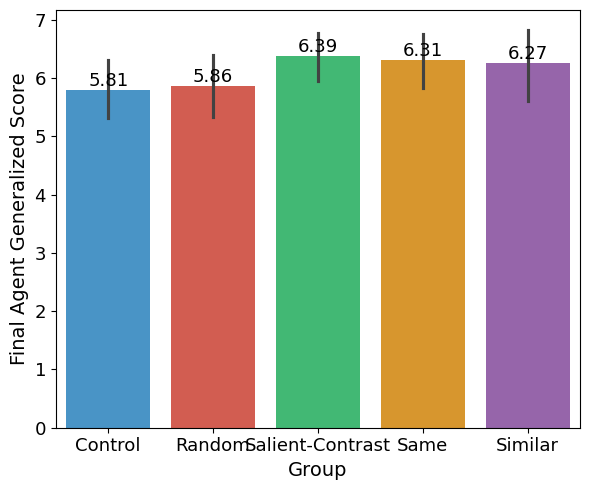

ANOVA F=1.1533, p=0.3322  |  Kruskal-Wallis H=4.8498, p=0.3031
         group_1          group_2      U      p
         Control           Random 1274.0 0.6363
         Control Salient-Contrast 1204.0 0.9608
         Control             Same 1212.0 0.9410
         Control          Similar  741.0 0.8902
          Random Salient-Contrast 1183.5 0.9235
          Random             Same 1196.0 0.8838
          Random          Similar  725.0 0.8332
Salient-Contrast             Same 1570.5 0.4264
Salient-Contrast          Similar  947.5 0.4187
            Same          Similar  916.0 0.4713


In [82]:
# Plot: Final Agent Generalized Score by Group
plot_barplot(user_results, 'group_label', 'final_agent_mean_score',
             y_label='Final Agent Generalized Score', estimator='mean',
             bar_label_fmt='%.2f', palette=colors_palette,)
anova_test(user_results, 'final_agent_mean_score', 'group_label')
mannwhitneyu_test(user_results, 'final_agent_mean_score', 'group_label', test_type='greater')

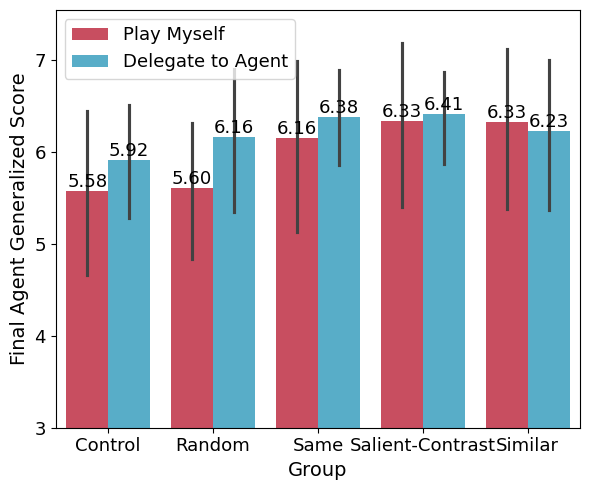


--- Same ---
 group_1  group_2     U      p
     0.0      1.0 315.5 0.4469

--- Similar ---
 group_1  group_2     U      p
     0.0      1.0 122.5 0.4533

--- Random ---
 group_1  group_2     U      p
     0.0      1.0 253.0 0.1267


In [83]:
# Plot: Final Agent Generalized Score by Group and Delegate
plot_barplot(user_results, 'group_label', 'final_agent_mean_score',
             y_label='Final Agent Generalized Score', hue='trust_the_agent',
             hue_names=['Play Myself', 'Delegate to Agent'],
             order=group_order,
             bar_label_fmt='%.2f', estimator='mean',
             palette=["#DC3A52", "#45B6DB"], ylim_bottom=3)

for grp in group_names:
    df_g = user_results[user_results['group_label'] == grp]
    if df_g['trust_the_agent'].nunique() > 1:
        print(f"\n--- {grp} ---")
        mannwhitneyu_test(df_g, 'final_agent_mean_score', 'trust_the_agent', test_type='less')

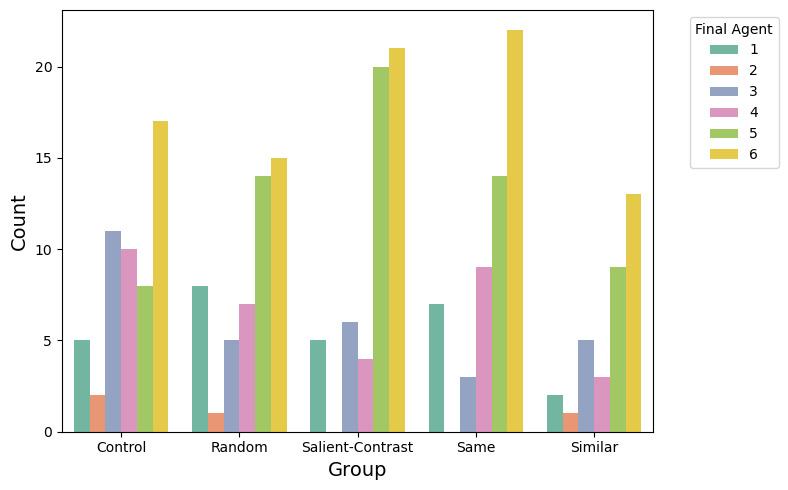

In [84]:
# Plot: Count of Final Agent by Group
grouped = user_results.groupby(['group_label', 'final_agent']).size().reset_index(name='count')
plt.figure(figsize=(8, 5))
sns.barplot(data=grouped, x='group_label', y='count', hue='final_agent',
            palette='Set2')
plt.legend(title='Final Agent', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel('Group', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()

In [85]:
choices_results['good_choice_global'].value_counts()

good_choice_global
1    558
0    219
Name: count, dtype: int64

<Figure size 800x500 with 0 Axes>

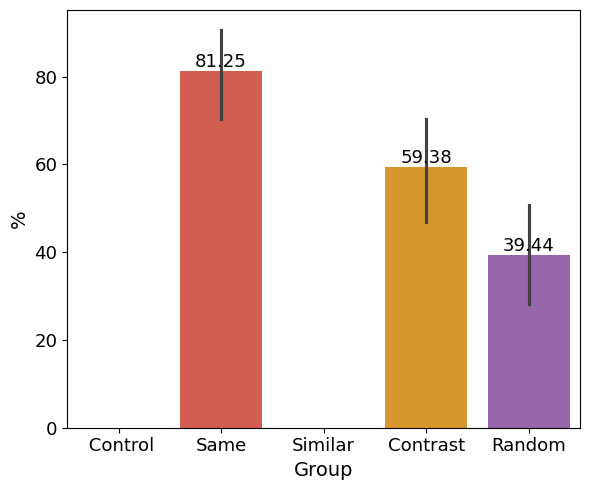

In [86]:
plt.figure(figsize=(8, 5))
plot_barplot(choices_results[choices_results['choice'] == 0], 'group_label', 'good_choice_local', 
                          bar_label_fmt='%.2f', palette=colors_palette,
             order=group_names, x_val_names=group_names)